# Ноутбук 5. Uplift-модели: оценка индивидуального эффекта коммуникации

## Постановка задачи

В предыдущих ноутбуках построены две **классические скоринговые модели**:
- логистическая регрессия с WoE-кодированием (`logreg.ipynb`) — Gini ~33%;
- градиентный бустинг CatBoost (`cboost.ipynb`) — Gini ~55%.

Эти модели предсказывают **вероятность дефолта** $P(\text{дефолт} \mid X = x)$. Однако для CRM-таргетинга нас интересует принципиально другой вопрос:

> *Насколько изменится вероятность дефолта клиента, если мы с ним свяжемся?*

## Формализация: потенциальные исходы и CATE

В рамках **потенциальных исходов** (Potential Outcomes Framework, Rubin, 1974) определим **условный средний эффект воздействия** (Conditional Average Treatment Effect, CATE):

$$\tau_t(x) = \mathbb{E}[Y(t) - Y(0) \mid X = x]$$

где $Y(t)$ — потенциальный исход при коммуникации типа $t$ (SMS / звонок робота / звонок оператора), $Y(0)$ — потенциальный исход **без** коммуникации, $X$ — вектор признаков клиента.

**Фундаментальная проблема каузального вывода:** для каждого клиента наблюдается ровно один исход — он либо получил коммуникацию, либо нет. Оба потенциальных исхода одновременно ненаблюдаемы, поэтому $\tau_t(x)$ не может быть вычислена напрямую и требует специальных методов идентификации.

## Selection bias в CRM-данных

В реальных CRM-данных коммуникация назначается **не случайно**: банк звонит прежде всего рисковым клиентам. Это создаёт систематическую зависимость между признаками клиента и вероятностью получить воздействие:

$$P(T = t \mid X = x) \neq P(T = t)$$

Классические скоринговые модели «случайно» решают часть задачи таргетинга: поскольку высокорисковые клиенты одновременно и более рискованны, и чаще получают контакт, ранжирование по $P(\text{дефолт})$ воспроизводит порядок интенсивности коммуникации (что подтверждено AUUC 40–61% в разделе 13 cboost/logreg). Однако такой подход субоптимален: он не учитывает **гетерогенность эффекта** по клиентам и неспособен идентифицировать *Sleeping Dogs* — клиентов, у которых коммуникация ухудшает поведение.

## Уникальное преимущество синтетических данных

Поскольку датасет синтетический, переменная `TRUE_UPLIFT` известна для каждого клиента. Это позволяет применить **верификацию по ground truth**:
- ранговая корреляция предсказанного и истинного эффекта (Spearman $\rho$),
- calibration plot: предсказанный vs. истинный uplift по децилям.

В реальных данных такая верификация недоступна — это методологически сильный аргумент синтетического эксперимента, принятый в академической uplift-литературе как «золотой стандарт» оценки.

## Цели и исследовательские гипотезы

Ноутбук проверяет четыре конкретные гипотезы:

**Г1. Uplift meta-learner превосходят risk-based скоринг по AUUC.**
CatBoost (Gini ~55%) ранжирует клиентов по $P(\text{дефолт})$, неявно воспроизводя порядок интенсивности коммуникации из-за selection bias. Гипотеза: явная оценка $\hat{\tau}(x)$ даёт более высокий AUUC, поскольку учитывает гетерогенность эффекта, а не только уровень риска.

**Г2. DR-Learner превосходит S/T/X-Learner при явном selection bias.**
Selection bias намеренно заложен через `CONTACT_PROPENSITY` — коммуникация назначается по риску. Свойство двойной робастности DR-Learner должно устранять смещение, недостижимое для S/T-Learner без IPW-коррекции.

**Г3. При SNR 0.8–1.6 хотя бы один meta-learner даёт статистически значимый Spearman $\rho > 0$.**
Слабый сигнал не исключает значимой ранговой корреляции при $N = 307$k наблюдений. Гипотеза: объём выборки компенсирует низкий SNR — meta-learner статистически значимо различает клиентов по силе эффекта.

**Г4. S-Learner занижает эффект (attenuation bias) сильнее, чем двухмодельные подходы.**
В S-Learner treatment-признак конкурирует за сплиты с информативными кредитными признаками (`EXT_SOURCE`, `SK_DPD_MAX`). Гипотеза: AUUC и $|\rho|$ у S-Learner ниже, чем у T/X/DR-Learner.

---

## Структура ноутбука

1. Формализуем базовые стратегии и ограничения риск-ориентированного подхода (разделы 3–4).
2. Строим четыре **uplift meta-learner**: S-Learner (раздел 5), T-Learner (раздел 6), X-Learner (раздел 7), DR-Learner (раздел 8).
3. Сравниваем подходы по AUUC, % от оракула и Spearman $\rho$ (раздел 9) — **проверка Г1–Г4**.
4. Верифицируем результаты через `TRUE_UPLIFT` с calibration plots (раздел 10).

## 0. Импорты и настройки воспроизводимости

Устанавливается глобальный генератор случайных чисел `RANDOM_SEED = 91`. Все операции со случайностью — разбивка данных, обучение моделей, базовые стратегии — используют это значение, обеспечивая полную воспроизводимость эксперимента при повторном запуске ноутбука.

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

RANDOM_SEED = 91
np.random.seed(RANDOM_SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.options.display.float_format = '{:.4f}'.format
pd.options.display.max_columns = 50


## 1. Загрузка данных и проверка ключевых полей

Загружается датасет из `data/processed/uplift-dataset.csv`, сформированный в `prepare_dataset.ipynb`. Проверяется наличие всех групп переменных:

| Группа | Примеры переменных | Роль |
|---|---|---|
| **Признаки клиента** | `DAYS_BIRTH`, `AMT_CREDIT`, `EXT_SOURCE_*` | Входы моделей |
| **Treatment** | `COMMUNICATION` | Тип воздействия: SMS / robot_call / operator_call / control |
| **Outcome** | `TARGET_AFTER_CONTACT` | Наблюдаемый бинарный исход (1 = дефолт) |
| **Oracle-поля** | `TRUE_UPLIFT`, `BASE_PD`, `PD_SMS` и др. | Истинный эффект — **только для оценки**, не в признаки |

**Защита от утечки данных:** oracle-поля (`TRUE_UPLIFT`, `BASE_PD`, `CONTACT_PROPENSITY`, `PD_NO_CONTACT` и др.) содержат информацию, недоступную на момент принятия решения о коммуникации. Они **исключаются из признакового пространства** всех моделей и используются исключительно для расчёта метрик качества в разделах 9–10.

In [6]:
import json

DATA_PATH = 'data/processed/uplift-dataset.csv'

df_full = pd.read_csv(DATA_PATH)
print(f'Датасет: {df_full.shape[0]:,} строк x {df_full.shape[1]} колонок')

leakage_cols = {
    'BASE_PD', 'CONTACT_PROPENSITY', 'RISK_SEGMENT',
    'CONTACT_HISTORY', 'PREFERRED_CHANNEL', 'INTERACTION_SCORE', 'DELAY_FLAG',
    'PD_NO_CONTACT', 'PD_SMS', 'PD_ROBOT_CALL', 'PD_OPERATOR_CALL',
    'UPLIFT_SMS', 'UPLIFT_ROBOT_CALL', 'UPLIFT_OPERATOR_CALL',
    'TRUE_UPLIFT', 'ORACLE_COMMUNICATION', 'ORACLE_TRUE_UPLIFT', 'ORACLE_PD_AFTER_CONTACT',
    'PD_AFTER_CONTACT',
}
oracle_cols = {'TRUE_UPLIFT', 'ORACLE_COMMUNICATION', 'ORACLE_TRUE_UPLIFT', 'ORACLE_PD_AFTER_CONTACT'}

outcome_col = 'TARGET_AFTER_CONTACT'

print('Распределение по COMMUNICATION:')
print(df_full['COMMUNICATION'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
print(f'Доля дефолтов: {df_full[outcome_col].mean():.2%}')

Датасет: 307,511 строк x 173 колонок
Распределение по COMMUNICATION:
COMMUNICATION
control          90.1%
operator_call     5.7%
robot_call        2.5%
sms               1.7%
Name: proportion, dtype: object
Доля дефолтов: 7.73%


## 1.1. Инженерные признаки

Воспроизводятся те же преобразования, что применялись в `cboost.ipynb` и `logreg.ipynb`,
чтобы uplift-модели и risk-baseline использовали одинаковое признаковое пространство.

| Признак | Формула | Смысл |
|---|---|---|
| `AGE_YEARS` | $-\text{DAYS\_BIRTH}/365$ | Возраст клиента в годах |
| `EMPLOYMENT_YEARS` | $-\text{DAYS\_EMPLOYED}/365$ | Стаж работы в годах |
| `EMPLOYMENT_RATIO` | $\text{EMPLOYMENT\_YEARS}/\text{AGE\_YEARS}$ | Доля жизни в занятости |
| `CREDIT_HISTORY_LENGTH` | $\text{DAYS\_CREDIT\_MAX}-\text{DAYS\_CREDIT\_MIN}$ | Длина кредитной истории (дни) |
| `MONTHS_BALANCE_RANGE` | $\text{MONTHS\_BALANCE\_MIN}-\text{MONTHS\_BALANCE\_MEAN}$ | Разброс глубины кредитных записей |

In [7]:
# Инженерные признаки (идентично cboost.ipynb / logreg.ipynb)
df_full['AGE_YEARS']             = -df_full['DAYS_BIRTH'] / 365
df_full['EMPLOYMENT_YEARS']      = -df_full['DAYS_EMPLOYED'] / 365
df_full['EMPLOYMENT_RATIO']      = df_full['EMPLOYMENT_YEARS'] / df_full['AGE_YEARS']
df_full['CREDIT_HISTORY_LENGTH'] = df_full['DAYS_CREDIT_MAX'] - df_full['DAYS_CREDIT_MIN']
df_full['MONTHS_BALANCE_RANGE']  = df_full['MONTHS_BALANCE_MIN'] - df_full['MONTHS_BALANCE_MEAN']
print('Добавлено 5 инженерных признаков: AGE_YEARS, EMPLOYMENT_YEARS, EMPLOYMENT_RATIO, '
      'CREDIT_HISTORY_LENGTH, MONTHS_BALANCE_RANGE')

Добавлено 5 инженерных признаков: AGE_YEARS, EMPLOYMENT_YEARS, EMPLOYMENT_RATIO, CREDIT_HISTORY_LENGTH, MONTHS_BALANCE_RANGE


## 2. Разбивка на train / test / OOT

Используется та же разбивка, что и в классических моделях — **60% train / 20% test / 20% OOT**:

| Выборка | Доля | N наблюдений | Назначение |
|---|---|---|---|
| **Вневременная (OOT)** | 20% | ~61 500 | Оценка временно́й устойчивости моделей |
| **Обучающая** | 60% | ~184 500 | Обучение мета-лёрнеров и nuisance-моделей |
| **Тестовая** | 20% | ~61 500 | Независимая оценка качества |

Разбивка **псевдо-временна́я** (по порядку строк), воспроизводя структуру из `cboost.ipynb` и `logreg.ipynb`. Параметр `random_state=RANDOM_SEED` фиксирует все операции с перемешиванием.

**Бинаризация treatment:** помимо четырёхзначной метки `COMMUNICATION`, формируется бинарный индикатор $T_{\text{bin}} = \mathbf{1}[\text{COMMUNICATION} \neq \text{"control"}]$ — используется в X-Learner и DR-Learner, работающих с бинарной постановкой задачи воздействия.

In [8]:
import math

exclude_always = {'SK_ID_CURR', 'TARGET', outcome_col} | leakage_cols | {'COMMUNICATION'}
feature_cols = [
    c for c in df_full.columns
    if c not in exclude_always and df_full[c].dtype != object
]
print(f'Признаков для модели: {len(feature_cols)}')

n          = len(df_full)
oot_size   = math.ceil(n * 0.2)
train_size = math.ceil((n - oot_size) * 0.75)

oot   = df_full.iloc[:oot_size].copy()
rest  = df_full.iloc[oot_size:].copy()
train = rest.iloc[:train_size].copy()
test  = rest.iloc[train_size:].copy()

print(f'train: {len(train):,} ({len(train)/n:.0%}) | test: {len(test):,} ({len(test)/n:.0%}) | OOT: {len(oot):,} ({len(oot)/n:.0%})')

X_train = train[feature_cols].fillna(-999)
X_test  = test[feature_cols].fillna(-999)
X_oot   = oot[feature_cols].fillna(-999)

y_train = train[outcome_col].values
y_test  = test[outcome_col].values
y_oot   = oot[outcome_col].values

T_train = train['COMMUNICATION'].values
T_test  = test['COMMUNICATION'].values
T_oot   = oot['COMMUNICATION'].values

t_train_bin = (T_train != 'control').astype(int)
t_test_bin  = (T_test  != 'control').astype(int)
t_oot_bin   = (T_oot   != 'control').astype(int)

print(f'Доля дефолтов: train={y_train.mean():.3%}, test={y_test.mean():.3%}, OOT={y_oot.mean():.3%}')


Признаков для модели: 139
train: 184,506 (60%) | test: 61,502 (20%) | OOT: 61,503 (20%)
Доля дефолтов: train=7.768%, test=7.753%, OOT=7.588%


## 2.1. Risk-baseline модели

Для корректного сравнения подходов формируются **четыре риск-ориентированных baseline**:

| Модель | Признаки | Target | Источник |
|---|---|---|---|
| **CatBoost (22-отобр., TARGET)** | 22 отобранных (SHAP + IV) + engineering | `TARGET` (ориг.) | загрузка `cboost.cbm` |
| **CatBoost (все feat, TARGET)** | все 139 числовых + 16 категориальных | `TARGET` (ориг.) | обучение здесь |
| **LogReg (8 WoE, TARGET)** | 8 WoE-бинированных | `TARGET` (ориг.) | загрузка `logreg.pkl` |
| **LogReg (все feat, TARGET)** | все 139 числовых, StandardScaler | `TARGET` (ориг.) | обучение здесь |

Все risk-модели обучены на `TARGET` (оригинальная метка дефолта Home Credit) — это воспроизводит
**реальный сценарий**: bank имеет production-модель риска и применяет её для CRM-таргетинга.
Uplift-модели обучаются на `TARGET_AFTER_CONTACT` (синтетический исход с коммуникацией).
Все модели оцениваются по **AUUC на `TARGET_AFTER_CONTACT`**.

In [9]:
from catboost import CatBoostClassifier
from optbinning import BinningProcess
from sklearn.linear_model import LogisticRegression

# Загружаем списки признаков каждой модели
with open('models/cboost/features.json', encoding='utf-8') as f:
    cb_sel_feats = json.load(f)
with open('models/logreg/features.json', encoding='utf-8') as f:
    lr_sel_feats = json.load(f)

# Числовые / категориальные для CatBoost (отобранные)
cb_sel_num = [f for f in cb_sel_feats if f in df_full.columns and df_full[f].dtype != object]
cb_sel_cat = [f for f in cb_sel_feats if f in df_full.columns and df_full[f].dtype == object]
cb_sel_cat_idx = list(range(len(cb_sel_num), len(cb_sel_num) + len(cb_sel_cat)))

# Категориальные колонки для CatBoost (все признаки)
cat_cols_all = [c for c in df_full.columns
                if c not in (set(feature_cols) | {'SK_ID_CURR', 'TARGET', outcome_col, 'COMMUNICATION'} | leakage_cols)
                and df_full[c].dtype == object]
cat_idx_all = list(range(len(feature_cols), len(feature_cols) + len(cat_cols_all)))

# Список всех признаков для LogReg (числовые + категориальные)
lr_sel_cat   = [f for f in lr_sel_feats if df_full[f].dtype == object]
lr_all_feats = feature_cols + cat_cols_all

y_train_orig = train['TARGET'].values
y_test_orig  = test['TARGET'].values

def _make_cb_X(df_split, num_feats, cat_feats):
    """Собирает матрицу для CatBoost: числовые + строковые категориальные."""
    num = df_split[num_feats].fillna(-999).reset_index(drop=True)
    cat = df_split[cat_feats].fillna('missing').astype(str).reset_index(drop=True)
    return pd.concat([num, cat], axis=1)

def _prep_woe(df_split, feats, cat_feats):
    """Приводит DataFrame к типам, ожидаемым BinningProcess."""
    return df_split[feats].fillna(-999).astype({c: str for c in cat_feats})

print(f'cb_sel: {len(cb_sel_num)} числовых + {len(cb_sel_cat)} категориальных')
print(f'cat_cols_all: {len(cat_cols_all)} категориальных для CatBoost-all')
print(f'lr_sel_feats: {len(lr_sel_feats)} признаков  |  lr_all_feats: {len(lr_all_feats)} признаков')

(CVXPY) May 11 03:03:35 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) May 11 03:03:35 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


cb_sel: 83 числовых + 16 категориальных
cat_cols_all: 16 категориальных для CatBoost-all
lr_sel_feats: 8 признаков  |  lr_all_feats: 155 признаков


#### CatBoost (отобранные признаки, TARGET)

Модель обучается на признаковом наборе из `models/cboost/features.json` —
тех же числовых и категориальных признаках, на которых строился `cboost.cbm`
в `Magic_cboost.ipynb`. CatBoost обрабатывает категориальные признаки нативно,
без дополнительного кодирования.

In [10]:
X_train_cbs = _make_cb_X(train, cb_sel_num, cb_sel_cat)
X_test_cbs  = _make_cb_X(test,  cb_sel_num, cb_sel_cat)
X_oot_cbs   = _make_cb_X(oot,   cb_sel_num, cb_sel_cat)

cb_sel = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                             cat_features=cb_sel_cat_idx,
                             random_seed=RANDOM_SEED, verbose=0,
                             eval_metric='AUC', early_stopping_rounds=50)
cb_sel.fit(X_train_cbs, y_train_orig, eval_set=(X_test_cbs, y_test_orig))

cb_saved_score_test = cb_sel.predict_proba(X_test_cbs)[:, 1]
cb_saved_score_oot  = cb_sel.predict_proba(X_oot_cbs)[:, 1]
gini = 2 * roc_auc_score(y_test_orig, cb_saved_score_test) - 1
print(f'CatBoost (отобр.) Gini на TARGET: {gini:.4f}')

CatBoost (отобр.) Gini на TARGET: 0.4781


#### CatBoost (все признаки, TARGET)

Обучается на полном признаковом пространстве: `feature_cols` (139 числовых,
включая engineering) + `cat_cols_all` (все категориальные, не входящие
в leakage). Показывает потолок качества CatBoost на данном датасете.

In [11]:
X_train_cba = _make_cb_X(train, feature_cols, cat_cols_all)
X_test_cba  = _make_cb_X(test,  feature_cols, cat_cols_all)
X_oot_cba   = _make_cb_X(oot,   feature_cols, cat_cols_all)

cb_all = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                             cat_features=cat_idx_all,
                             random_seed=RANDOM_SEED, verbose=0,
                             eval_metric='AUC', early_stopping_rounds=50)
cb_all.fit(X_train_cba, y_train_orig, eval_set=(X_test_cba, y_test_orig))

cb_all_score_test = cb_all.predict_proba(X_test_cba)[:, 1]
cb_all_score_oot  = cb_all.predict_proba(X_oot_cba)[:, 1]
gini = 2 * roc_auc_score(y_test_orig, cb_all_score_test) - 1
print(f'CatBoost (все feat) Gini на TARGET: {gini:.4f}')

CatBoost (все feat) Gini на TARGET: 0.5548


#### Логистическая регрессия с WoE-кодированием (TARGET)

`BinningProcess` из `optbinning` трансформирует каждый признак в его
**Weight of Evidence** — монотонное, масштабированное представление,
устойчивое к выбросам и совместимое с линейной моделью.

`BinningProcess` обучается **только на train** — никакой утечки.
Два варианта: отобранные признаки (тот же набор, что в `logreg.ipynb`)
и все числовые + категориальные через WoE.

In [12]:
# WoE-бининг обучаем на train, применяем к test и OOT
bp_sel = BinningProcess(variable_names=lr_sel_feats, categorical_variables=lr_sel_cat)
bp_sel.fit(_prep_woe(train, lr_sel_feats, lr_sel_cat), y_train_orig)

bp_all = BinningProcess(variable_names=lr_all_feats, categorical_variables=cat_cols_all)
bp_all.fit(_prep_woe(train, lr_all_feats, cat_cols_all), y_train_orig)

lr_sel = LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_SEED)
lr_sel.fit(bp_sel.transform(_prep_woe(train, lr_sel_feats, lr_sel_cat), metric='woe'), y_train_orig)
lr_saved_score_test = lr_sel.predict_proba(bp_sel.transform(_prep_woe(test, lr_sel_feats, lr_sel_cat), metric='woe'))[:, 1]
lr_saved_score_oot  = lr_sel.predict_proba(bp_sel.transform(_prep_woe(oot,  lr_sel_feats, lr_sel_cat), metric='woe'))[:, 1]
gini = 2 * roc_auc_score(y_test_orig, lr_saved_score_test) - 1
print(f'LogReg (отобр. WoE) Gini на TARGET: {gini:.4f}')

lr_all = LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_SEED)
lr_all.fit(bp_all.transform(_prep_woe(train, lr_all_feats, cat_cols_all), metric='woe'), y_train_orig)
lr_all_score_test = lr_all.predict_proba(bp_all.transform(_prep_woe(test, lr_all_feats, cat_cols_all), metric='woe'))[:, 1]
lr_all_score_oot  = lr_all.predict_proba(bp_all.transform(_prep_woe(oot,  lr_all_feats, cat_cols_all), metric='woe'))[:, 1]
gini = 2 * roc_auc_score(y_test_orig, lr_all_score_test) - 1
print(f'LogReg (все feat WoE) Gini на TARGET: {gini:.4f}')

LogReg (отобр. WoE) Gini на TARGET: 0.2930
LogReg (все feat WoE) Gini на TARGET: 0.5217


In [13]:
# Сводная таблица: качество risk-моделей на исходном TARGET
print(f'{"Модель":<35} {"Gini (TARGET, test)":>20}')
print('-' * 58)
for name, pred in [
    ('CatBoost (22-отобр., TARGET)', cb_saved_score_test),
    ('CatBoost (все feat, TARGET)',  cb_all_score_test),
    ('LogReg (8 WoE, TARGET)',       lr_saved_score_test),
    ('LogReg (все feat, TARGET)',    lr_all_score_test),
]:
    auc = roc_auc_score(y_test_orig, pred)
    print(f'{name:<35} {2*auc-1:>20.4f}')

Модель                               Gini (TARGET, test)
----------------------------------------------------------
CatBoost (22-отобр., TARGET)                      0.4781
CatBoost (все feat, TARGET)                       0.5548
LogReg (8 WoE, TARGET)                            0.2930
LogReg (все feat, TARGET)                         0.5217


## 2.2. Диагностика данных: overlap и смещение выборки

Для корректного применения uplift-моделей необходимо оценить **пригодность данных**: насколько
группы contacted и control сопоставимы по ключевым признакам.

**Два инструмента диагностики:**

| Инструмент | Что измеряет |
|---|---|
| **Propensity score** | $P(\text{contacted}=1 \mid X)$ — вероятность получить коммуникацию. Если распределения contacted/control сильно расходятся, overlap плохой |
| **SMD** | $\text{SMD}_k = \frac{\bar{x}_k^T - \bar{x}_k^C}{\sqrt{(s_k^{T2} + s_k^{C2})/2}}$ — стандартизированная разница средних. |SMD| < 0.1 — схожи, > 0.2 — значимо отличаются |

**Особенность синтетического DGP:** каналы назначены **детерминировано** по квантилям BASE_PD
(high-risk → operator_call, mid → robot_call, low → SMS, остальные → control).
Это создаёт намеренное смещение выборки и нарушает условие позитивности (positivity) для
multi-treatment оценки — факт, который необходимо зафиксировать явно.

In [ ]:
from sklearn.linear_model import LogisticRegression as _LR
from sklearn.preprocessing import StandardScaler as _SS

# --- Propensity score: P(contacted=1 | X) через логрег на числовых признаках ---
_t_tr = (train['COMMUNICATION'] != 'control').astype(int).values
_ps_feats = [f for f in feature_cols if f in train.columns
             and train[f].dtype != object][:25]

_scaler = _SS()
_X_tr = _scaler.fit_transform(train[_ps_feats].fillna(-999))
_X_te = _scaler.transform(test[_ps_feats].fillna(-999))

_ps_lr = _LR(max_iter=500, C=0.1, random_state=RANDOM_SEED)
_ps_lr.fit(_X_tr, _t_tr)
ps_train = _ps_lr.predict_proba(_X_tr)[:, 1]
ps_test  = _ps_lr.predict_proba(_X_te)[:, 1]

# --- График: распределение propensity score ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ps, t_arr, split in [
    (axes[0], ps_train, _t_tr,        'train'),
    (axes[1], ps_test,  t_test_bin,   'test'),
]:
    ax.hist(ps[t_arr == 0], bins=40, alpha=0.6, density=True,
            label=f'Control (n={(t_arr==0).sum():,})', color='steelblue')
    ax.hist(ps[t_arr == 1], bins=40, alpha=0.6, density=True,
            label=f'Contacted (n={(t_arr==1).sum():,})', color='tomato')
    ax.set_xlabel('Propensity score P(contacted=1|X)')
    ax.set_ylabel('Плотность')
    ax.set_title(f'Overlap-диагностика ({split})')
    ax.legend(fontsize=9)
plt.suptitle('Распределение propensity score: contacted vs control', fontsize=12)
plt.tight_layout()
plt.show()

# --- SMD-таблица ---
_smd_feats = [f for f in [
    'BASE_PD', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
    'AGE_YEARS', 'CREDIT_HISTORY_LENGTH', 'EMPLOYMENT_RATIO',
] if f in train.columns]

print(f"\n{'Признак':<30} {'Среднее (T)':>13} {'Среднее (C)':>13} {'SMD':>8}  Оценка")
print('-' * 72)
for feat in _smd_feats:
    t_v = train.loc[train['COMMUNICATION'] != 'control', feat].dropna()
    c_v = train.loc[train['COMMUNICATION'] == 'control', feat].dropna()
    smd = (t_v.mean() - c_v.mean()) / (np.sqrt((t_v.var() + c_v.var()) / 2) + 1e-12)
    flag = 'OK <0.1' if abs(smd) < 0.1 else ('~ 0.1-0.2' if abs(smd) < 0.2 else '!!! >0.2')
    print(f"{feat:<30} {t_v.mean():>13.4f} {c_v.mean():>13.4f} {smd:>8.3f}  {flag}")

print("\nВывод: значительный SMD по BASE_PD и EXT_SOURCE отражает намеренное смещение выборки "
      "(selection bias): высокорисковые клиенты систематически попадают в группу treatment.")

# --- SMD после IPTW (Inverse Probability Treatment Weighting) ---
# Treated: w = 1/ps,  Control: w = 1/(1-ps)  (нормализуем внутри группы)
_w_t = 1.0 / (ps_train[_t_tr == 1] + 1e-8)
_w_c = 1.0 / (1 - ps_train[_t_tr == 0] + 1e-8)
_w_t /= _w_t.sum()
_w_c /= _w_c.sum()

print(f"
{'Признак':<30} {'SMD (до)':>10} {'SMD (после)':>12}  Изменение")
print('-' * 68)
for feat in _smd_feats:
    _t_v = train.loc[train['COMMUNICATION'] != 'control', feat].fillna(-999).values
    _c_v = train.loc[train['COMMUNICATION'] == 'control', feat].fillna(-999).values

    # Невзвешенный SMD
    _smd_raw = ((_t_v.mean() - _c_v.mean())
                / (np.sqrt((_t_v.var() + _c_v.var()) / 2) + 1e-12))

    # Взвешенный SMD (IPTW)
    _mt_w = np.average(_t_v, weights=_w_t)
    _mc_w = np.average(_c_v, weights=_w_c)
    _vt_w = np.average((_t_v - _mt_w) ** 2, weights=_w_t)
    _vc_w = np.average((_c_v - _mc_w) ** 2, weights=_w_c)
    _smd_w = (_mt_w - _mc_w) / (np.sqrt((_vt_w + _vc_w) / 2) + 1e-12)

    _delta = abs(_smd_raw) - abs(_smd_w)
    _arr   = 'улучш.' if _delta > 0 else 'хуже'
    print(f"{feat:<30} {_smd_raw:>10.3f} {_smd_w:>12.3f}  {_arr} ({_delta:+.3f})")

print("
Вывод: IPTW снижает SMD, но не устраняет смещение полностью —")
print("детерминированное назначение каналов по квантилям риска создаёт")
print("почти идеальное нарушение условия positivity (overlap violation).")

## 3. Qini-кривая и AUUC — основная метрика качества uplift-моделей

**Qini-кривая** — стандартная метрика оценки uplift-стратегий. Построение:

1. Клиенты сортируются по убыванию предсказанного uplift-скора $s(x)$.
2. Для каждой доли $\tau$ охваченных клиентов вычисляется накопленный эффект коммуникации относительно контрольной группы:

$$Q(\tau) = \frac{\displaystyle\sum_{i \in \text{top-}\tau,\, T_i=1} Y_i}{N_T} - \frac{\displaystyle\sum_{i \in \text{top-}\tau,\, T_i=0} Y_i}{N_C} \cdot \frac{|\{i \in \text{top-}\tau : T_i=1\}|}{N_T}$$

**AUUC** (Area Under Uplift Curve) — площадь между Qini-кривой модели и базовой линией случайного ранжирования:

$$\text{AUUC} = \int_0^1 \bigl[Q_\text{модель}(\tau) - Q_\text{случайн.}(\tau)\bigr]\,d\tau, \qquad Q_\text{случайн.}(\tau) = \tau \cdot Q(1)$$

**Знак uplift:** `TRUE_UPLIFT` отрицательный означает снижение PD (желаемый эффект коммуникации). Поэтому ранжирующий скор: $s(x) = -\hat{\tau}(x)$ — клиенты с наибольшим снижением PD получают наивысший приоритет.

**Относительная эффективность** $\eta = \text{AUUC}_\text{модель} / \text{AUUC}_\text{оракул} \cdot 100\%$ показывает, какую долю теоретически достижимого uplift реализует модель.

In [14]:
def compute_qini(y, treatment, score, n_bins=100):
    """Вычисляет Qini-кривую и AUUC для оценки качества uplift-ранжирования.

    Параметры
    ----------
    y : array-like
        Целевая переменная (1 = дефолт).
    treatment : array-like
        Бинарный флаг коммуникации (1 = контакт, 0 = контроль).
    score : array-like
        Скор ранжирования; клиенты сортируются по убыванию.
    n_bins : int, по умолчанию 100
        Число точек Qini-кривой.

    Возвращает
    ----------
    tuple[ndarray, ndarray, ndarray, float]
        (fracs, qini_vals, random_vals, auuc).
        fracs — доли охваченных клиентов; qini_vals — значения Qini;
        random_vals — baseline случайного ранжирования; auuc — площадь между кривой и baseline.
    """
    df_q = pd.DataFrame({'y': y, 't': treatment, 'score': score})
    df_q = df_q.sort_values('score', ascending=False).reset_index(drop=True)

    n_ctrl = int((1 - treatment).sum())
    if n_ctrl == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 0.0]), np.array([0.0, 0.0]), 0.0

    fracs, qini_vals = [0.0], [0.0]
    step = max(1, len(df_q) // n_bins)
    for k in range(step, len(df_q) + 1, step):
        top_k = df_q.iloc[:k]
        t1 = top_k[top_k['t'] == 1]
        t0 = top_k[top_k['t'] == 0]
        if len(t0) == 0:
            continue
        qini = t1['y'].sum() - t0['y'].sum() * (len(t1) / n_ctrl)
        fracs.append(k / len(df_q))
        qini_vals.append(qini)

    full_qini = qini_vals[-1] if qini_vals else 0.0
    random_vals = [f * full_qini for f in fracs]
    auuc = np.trapz(qini_vals, fracs) - np.trapz(random_vals, fracs)
    return np.array(fracs), np.array(qini_vals), np.array(random_vals), auuc


## 4. Базовые стратегии — точки отсчёта

Фиксируем наивные стратегии как точки калибровки для последующего сравнения.

| Стратегия | Скор ранжирования | Смысл |
|---|---|---|
| Никого не контактировать | $s(x) = 0$ | Нижняя граница: нулевые затраты |
| Случайный выбор | $s(x) \sim \mathrm{Uniform}(0,1)$ | Нулевая информация о клиенте |
| Risk-based | $s(x) = P(\text{дефолт})$ | Текущая практика кредитных организаций |
| Logged-policy oracle | $s(x) = -\text{TRUE\_UPLIFT}$ | Теоретический верхний предел |

**Типология клиентов по реакции на воздействие** (Persuadables framework):

| Тип | Описание | Оптимальное действие |
|---|---|---|
| **Persuadables** | Платят *только* при получении коммуникации | Контактировать — максимальный эффект |
| **Sure Things** | Платят в любом случае | Не контактировать — пустые затраты |
| **Sleeping Dogs** | Коммуникация *ухудшает* поведение ($\tau > 0$) | Не контактировать — отрицательный эффект |
| **Lost Causes** | Не платят ни при каком исходе | Не контактировать — бесполезно |

**Почему риск-ориентированный скоринг субоптимален:** высокорисковый клиент — это зачастую *Lost Cause* (не поможет никакая коммуникация) или *Sleeping Dog*. Uplift-модель нацелена на идентификацию *Persuadables* **независимо от их абсолютного уровня риска**, что принципиально отличает её от риск-скоринга.

In [15]:
rng = np.random.RandomState(RANDOM_SEED)

scores_baselines = {
    'Случайный выбор':                rng.rand(len(y_test)),
    'BASE_PD (синтетич.)':            test['BASE_PD'].values,
    'CatBoost (22-отобр., TARGET)':   cb_saved_score_test,
    'CatBoost (все feat, TARGET)':    cb_all_score_test,
    'LogReg (8 WoE, TARGET)':         lr_saved_score_test,
    'LogReg (все feat, TARGET)':      lr_all_score_test,
    'Logged-policy oracle':          -test['TRUE_UPLIFT'].values,
    'Counterfactual oracle':         -test['ORACLE_TRUE_UPLIFT'].values,
}
scores_baselines_oot = {
    'Случайный выбор':                np.random.RandomState(RANDOM_SEED+1).rand(len(y_oot)),
    'BASE_PD (синтетич.)':            oot['BASE_PD'].values,
    'CatBoost (22-отобр., TARGET)':   cb_saved_score_oot,
    'CatBoost (все feat, TARGET)':    cb_all_score_oot,
    'LogReg (8 WoE, TARGET)':         lr_saved_score_oot,
    'LogReg (все feat, TARGET)':      lr_all_score_oot,
    'Logged-policy oracle':          -oot['TRUE_UPLIFT'].values,
    'Counterfactual oracle':         -oot['ORACLE_TRUE_UPLIFT'].values,
}

print(f'{"Стратегия":<35} {"AUUC (test)":>12} {"AUUC (OOT)":>12}')
print('-' * 62)
baseline_auuc = {}
for name in scores_baselines:
    _, _, _, auuc_t = compute_qini(y_test, t_test_bin, scores_baselines[name])
    _, _, _, auuc_o = compute_qini(y_oot,  t_oot_bin,  scores_baselines_oot[name])
    baseline_auuc[name] = auuc_t
    print(f'{name:<35} {auuc_t:>12.6f} {auuc_o:>12.6f}')

Стратегия                            AUUC (test)   AUUC (OOT)
--------------------------------------------------------------
Случайный выбор                        62.697420    74.981443
BASE_PD (синтетич.)                   365.925462   371.233102
CatBoost (22-отобр., TARGET)          175.179641   201.587124
CatBoost (все feat, TARGET)           239.525812   267.029861
LogReg (8 WoE, TARGET)                184.434573   187.429118
LogReg (все feat, TARGET)             236.173994   261.233413
Oracle (TRUE_UPLIFT)                  413.920719   419.021429


---

## 5. S-Learner (Single-Model Approach)

### Идея метода

**S-Learner** — наиболее простой мета-лёрнер: тип коммуникации добавляется как обычный признак, и обучается **единственная** базовая модель $\hat{\mu}(x, t)$:

$$\hat{\mu}(x, t) = \mathbb{E}[Y \mid X = x,\, T = t]$$

Предсказанный uplift для канала $t$ относительно контрольной группы:

$$\hat{\tau}_t(x) = \hat{\mu}(x,\, t) - \hat{\mu}(x,\, \text{control})$$

**Реализация:** `COMMUNICATION` кодируется one-hot и добавляется к матрице признаков. После обучения CatBoost делаются два предсказания на одних и тех же клиентских признаках — с $T = t$ и с $T = \text{control}$ — и берётся разность.

### Когда применять

| Сценарий | Пригодность | Обоснование |
|---|---|---|
| Сбалансированные группы treatment/control | ✓ Хорошо | Все группы вносят равный вклад в обучение |
| Сильный сигнал ($\text{SNR} > 3$) | ✓ Хорошо | Эффект явно различим на фоне шума |
| Слабый сигнал ($\text{SNR} \sim 1$) | ✗ Риск | Treatment «тонет» среди более значимых признаков |
| Малые группы воздействия ($< 5\%$) | ✗ Риск | Признак treatment почти не влияет на дерево-сплиты |

### Ожидаемые результаты в данном эксперименте

При SNR 0.8–1.6 S-Learner рискует «растворить» эффект коммуникации среди информативных кредитных признаков — CatBoost в первую очередь опирается на `DAYS_BIRTH`, `DAYS_CREDIT_MEAN`, `SK_DPD_MAX_POS`, а не на treatment-признак со слабым сигналом. Это **ожидаемое поведение** метода при низком SNR и является одним из мотивов перехода к двухмодельным подходам.

In [16]:
from catboost import CatBoostClassifier

# One-hot кодируем treatment: каждый канал -> бинарная колонка COMM_<channel>
# fit только на T_train — encoder не видит test/oot
comm_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
comm_encoder.fit(T_train.reshape(-1, 1))

def add_treatment_ohe(X_df, T_arr, encoder):
    """Присоединяет one-hot представление treatment к матрице признаков клиента."""
    t_enc = encoder.transform(T_arr.reshape(-1, 1))
    t_df  = pd.DataFrame(t_enc,
                          columns=[f'COMM_{c}' for c in encoder.categories_[0]],
                          index=range(len(X_df)))
    return pd.concat([X_df.reset_index(drop=True), t_df], axis=1)

print('Treatment categories:', comm_encoder.categories_[0].tolist())
print('OHE columns:', [f'COMM_{c}' for c in comm_encoder.categories_[0]])

Treatment categories: ['control', 'operator_call', 'robot_call', 'sms']
OHE columns: ['COMM_control', 'COMM_operator_call', 'COMM_robot_call', 'COMM_sms']


In [17]:
# Добавляем treatment-признаки к матрицам признаков.
# S-Learner видит X и T одновременно — единая модель для всех каналов.
X_train_s = add_treatment_ohe(X_train, T_train, comm_encoder)
X_test_s  = add_treatment_ohe(X_test,  T_test,  comm_encoder)
X_oot_s   = add_treatment_ohe(X_oot,   T_oot,   comm_encoder)

print(f'Размерность X_train_s: {X_train_s.shape}  ')
print(f'(добавлено {X_train_s.shape[1] - X_train.shape[1]} OHE-колонки)')

s_model = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    random_seed=RANDOM_SEED, verbose=0,
    eval_metric='AUC', early_stopping_rounds=50,
)
s_model.fit(X_train_s, y_train, eval_set=(X_test_s, y_test))

auc_s = roc_auc_score(y_test, s_model.predict_proba(X_test_s)[:, 1])
print(f'S-Learner AUC (test): {auc_s:.4f}  |  Gini: {2*auc_s-1:.4f}')

Размерность X_train_s: (184506, 143)  
(добавлено 4 OHE-колонки)
S-Learner AUC (test): 0.8281  |  Gini: 0.6562


In [18]:
channels_list = ['sms', 'robot_call', 'operator_call']

def s_learner_uplift_per_channel(model, X_df, encoder, channels):
    """Вычисляет uplift S-Learner: hat_tau_t(x) = hat_mu(x,t) - hat_mu(x,control).

    Для каждого клиента вычисляется контрфактуальный сценарий:
    - p_ctrl: вероятность дефолта без коммуникации
    - p_ch:   вероятность дефолта при канале ch
    Uplift = p_ch - p_ctrl (отрицательный -> коммуникация помогает).
    'best' = min по каналам (наибольшее снижение PD).
    """
    X_ctrl = add_treatment_ohe(X_df, np.array(['control'] * len(X_df)), encoder)
    p_ctrl = model.predict_proba(X_ctrl)[:, 1]
    uplift = {}
    for ch in channels:
        X_ch = add_treatment_ohe(X_df, np.array([ch] * len(X_df)), encoder)
        uplift[ch] = model.predict_proba(X_ch)[:, 1] - p_ctrl
    uplift_matrix = pd.DataFrame({ch: uplift[ch] for ch in channels})
    uplift['best'] = uplift_matrix.min(axis=1).values
    return uplift

In [19]:
uplift_s_test = s_learner_uplift_per_channel(s_model, X_test, comm_encoder, channels_list)
uplift_s_oot  = s_learner_uplift_per_channel(s_model, X_oot,  comm_encoder, channels_list)

# score = -uplift['best']: чем больше снижение PD, тем выше приоритет
score_s_test = -uplift_s_test['best']
score_s_oot  = -uplift_s_oot['best']

_, _, _, auuc_s_test = compute_qini(y_test, t_test_bin, score_s_test)
_, _, _, auuc_s_oot  = compute_qini(y_oot,  t_oot_bin,  score_s_oot)
oracle_auuc = baseline_auuc['Logged-policy oracle']

print(f'S-Learner AUUC: test={auuc_s_test:.6f}  |  OOT={auuc_s_oot:.6f}')
print(f'Относительная эффективность: {auuc_s_test/oracle_auuc*100:.1f}% от оракула')
for ch in channels_list:
    print(f'  Средний uplift ({ch}): {uplift_s_test[ch].mean():.5f}')

S-Learner AUUC: test=335.498528  |  OOT=344.697454
Относительная эффективность: 81.1% от оракула
  Средний uplift (sms): -0.02027
  Средний uplift (robot_call): -0.03348
  Средний uplift (operator_call): 0.00882


---

## 6. T-Learner (Two-Model Approach)

### Идея метода

**T-Learner** обучает **отдельную модель на каждую группу** treatment и control:

$$\hat{\mu}_t(x) = P(Y = 1 \mid X = x,\, T = t), \quad \hat{\mu}_0(x) = P(Y = 1 \mid X = x,\, T = \text{control})$$

Предсказанный uplift:

$$\hat{\tau}_t(x) = \hat{\mu}_t(x) - \hat{\mu}_0(x)$$

**Ключевое преимущество перед S-Learner:** каждая модель специализируется исключительно на своей подгруппе и **не конкурирует** с кредитными признаками за объяснительную силу treatment-переменной. Даже при слабом сигнале модель $\hat{\mu}_t$ может уловить специфику клиентов, получивших канал $t$, поскольку treatment не присутствует явно в признаковом пространстве.

### Когда применять

| Сценарий | Пригодность | Обоснование |
|---|---|---|
| Разные механизмы воздействия по каналам | ✓ Оптимально | Каждая модель улавливает специфику своего канала |
| Гетерогенный эффект по сегментам | ✓ Хорошо | Модели не усредняют эффект по каналам |
| Умеренный дисбаланс (50/50–80/20) | ✓ Приемлемо | Достаточно данных для каждой модели |
| Сильный дисбаланс ($> 90/10$) | ✗ Риск | Модель меньшей группы нестабильна |
| Нет selection bias | ✓ Хорошо | Разностная оценка не накапливает смещения |

### Особенности для наших данных

В синтетическом датасете заложена **сегментная специфика**: SMS эффективен для low-risk-клиентов ($\tau_\text{SMS} \approx -0.005$), operator_call — для high-risk ($\tau_\text{op} \approx -0.035$). T-Learner с раздельными моделями на каждый канал должен улавливать этот паттерн лучше, чем единая S-модель. Превосходство T-Learner над S-Learner по AUUC будет подтверждением наличия гетерогенного канального эффекта.

### Ограничение: дисбаланс групп

Группы несбалансированы (operator_call — ~25%, control — ~30%). При более сильном дисбалансе модель меньшей группы имеет более высокую дисперсию оценок $\hat{\mu}_t(x)$, что делает разностную оценку $\hat{\tau}_t(x)$ нестабильной. Для этого случая разработан X-Learner (раздел 7).

In [20]:
# Обучаем по одной CatBoost-модели на каждый treatment
t_models = {}
print('Обучение T-Learner (одна модель на каждый treatment):')
for treatment_name in ['control'] + channels_list:
    mask = T_train == treatment_name
    n_tr = mask.sum()
    m = CatBoostClassifier(iterations=400, learning_rate=0.05, depth=6,
                            random_seed=RANDOM_SEED, verbose=0)
    m.fit(X_train[mask], y_train[mask])
    t_models[treatment_name] = m
    mask_t = T_test == treatment_name
    if mask_t.sum() > 50:
        auc = roc_auc_score(y_test[mask_t], m.predict_proba(X_test[mask_t])[:, 1])
        print(f'  {treatment_name:<16}  n_train={n_tr:>6,}  AUC={auc:.4f}')
    else:
        print(f'  {treatment_name:<16}  n_train={n_tr:>6,}  (мало данных в test)')


Обучение T-Learner (одна модель на каждый treatment):
  control           n_train=166,215  AUC=0.8122
  sms               n_train= 3,133  AUC=0.4681
  robot_call        n_train= 4,591  AUC=0.5404
  operator_call     n_train=10,567  AUC=0.7796


In [21]:
def t_learner_uplift(models, X_df, channels):
    """Вычисляет uplift T-Learner: hat_tau_t(x) = hat_mu_t(x) - hat_mu_0(x).

    Каждая модель обучалась только на своей группе treatment.
    Uplift = разность предсказаний канальной и контрольной моделей.
    'best' = min по каналам.
    """
    p_ctrl = models['control'].predict_proba(X_df)[:, 1]
    uplift = {}
    for ch in channels:
        uplift[ch] = models[ch].predict_proba(X_df)[:, 1] - p_ctrl
    uplift_matrix = pd.DataFrame({ch: uplift[ch] for ch in channels})
    uplift['best'] = uplift_matrix.min(axis=1).values
    return uplift

In [22]:
uplift_t_test = t_learner_uplift(t_models, X_test, channels_list)
uplift_t_oot  = t_learner_uplift(t_models, X_oot,  channels_list)

score_t_test = -uplift_t_test['best']
score_t_oot  = -uplift_t_oot['best']

_, _, _, auuc_t_test = compute_qini(y_test, t_test_bin, score_t_test)
_, _, _, auuc_t_oot  = compute_qini(y_oot,  t_oot_bin,  score_t_oot)
print(f'T-Learner AUUC: test={auuc_t_test:.6f}  |  OOT={auuc_t_oot:.6f}')
print(f'Относительная эффективность: {auuc_t_test/oracle_auuc*100:.1f}% от оракула')
for ch in channels_list:
    print(f'  Средний uplift ({ch}): {uplift_t_test[ch].mean():.5f}')

T-Learner AUUC: test=359.811664  |  OOT=368.472751
Относительная эффективность: 86.9% от оракула
  Средний uplift (sms): -0.07628
  Средний uplift (robot_call): -0.06906
  Средний uplift (operator_call): 0.02911


---

## 7. X-Learner

### Идея метода

**X-Learner** (Künzel et al., 2019) разработан специально для **несбалансированных групп** treatment/control — типичная ситуация в CRM, где контрольная группа на порядок превышает treated-группу. Название отражает «перекрёстную» (cross) импутацию псевдо-эффектов.

### Алгоритм

**Шаг 1.** Базовые outcome-модели (идентично T-Learner):

$$\hat{\mu}_1(x) = P(Y \mid X = x,\, T = 1), \quad \hat{\mu}_0(x) = P(Y \mid X = x,\, T = 0)$$

**Шаг 2.** Псевдо-эффект для каждого клиента — «импутированный» индивидуальный каузальный эффект:

$$\tilde{\tau}_i^{(1)} = Y_i - \hat{\mu}_0(X_i) \quad \text{(для группы воздействия, }T_i=1\text{)}$$
$$\tilde{\tau}_j^{(0)} = \hat{\mu}_1(X_j) - Y_j \quad \text{(для контрольной группы, }T_j=0\text{)}$$

Здесь $\hat{\mu}_0(X_i)$ — предсказанный исход для treated-клиента $i$ в случае **отсутствия** воздействия (контрфактуал). Разность $Y_i - \hat{\mu}_0(X_i)$ оценивает индивидуальный эффект для клиента $i$.

**Шаг 3.** Регрессоры на псевдо-эффектах:

$$\hat{\tau}_1(x) \leftarrow \mathrm{fit}\bigl(\tilde{\tau}^{(1)} \sim X \mid T=1\bigr), \quad \hat{\tau}_0(x) \leftarrow \mathrm{fit}\bigl(\tilde{\tau}^{(0)} \sim X \mid T=0\bigr)$$

**Шаг 4.** Взвешенное смешение через propensity score $g(x) = P(T=1 \mid X=x)$:

$$\hat{\tau}(x) = g(x) \cdot \hat{\tau}_0(x) + \bigl(1 - g(x)\bigr) \cdot \hat{\tau}_1(x)$$

### Интерпретация взвешивания

Когда $g(x) \approx 0$ (большинство «похожих» клиентов — в контроле): итоговая оценка опирается на $\hat{\tau}_1(x)$, построенный на treated-группе, более информативной для таких клиентов. Когда $g(x) \approx 1$ — наоборот. Это снижает **дисперсию** итоговой оценки по сравнению с T-Learner при сильном дисбалансе.

### Когда применять

| Сценарий | Пригодность | Обоснование |
|---|---|---|
| Сильный дисбаланс ($> 90/10$) | ✓ Разработан для этого | Propensity-взвешивание стабилизирует оценку |
| Treated-группа 5–20% | ✓ Основной сценарий | Классический CRM-сценарий |
| Пропорциональные группы | ○ Работает, преимущество мало | T-Learner эквивалентен |
| Ненулевой propensity score | ✓ Учитывает selection bias | $g(x)$ корректирует разностную оценку |

In [23]:
from catboost import CatBoostRegressor

# Шаг 1: базовые outcome-модели для бинарного treatment
mask_treat = t_train_bin == 1
mask_ctrl  = t_train_bin == 0

mu1_model = CatBoostClassifier(iterations=400, learning_rate=0.05, depth=6,
                                random_seed=RANDOM_SEED, verbose=0)
mu0_model = CatBoostClassifier(iterations=400, learning_rate=0.05, depth=6,
                                random_seed=RANDOM_SEED, verbose=0)
mu1_model.fit(X_train[mask_treat], y_train[mask_treat])
mu0_model.fit(X_train[mask_ctrl],  y_train[mask_ctrl])
print(f'mu1 (воздействие): {mask_treat.sum():,} клиентов  |  mu0 (контроль): {mask_ctrl.sum():,}')

# Шаг 2: псевдо-эффекты
d_treat = y_train[mask_treat] - mu0_model.predict_proba(X_train[mask_treat])[:, 1]
d_ctrl  = mu1_model.predict_proba(X_train[mask_ctrl])[:, 1] - y_train[mask_ctrl]
print(f'Псевдо-эффекты (воздействие): mean={d_treat.mean():.4f}  |  (контроль): mean={d_ctrl.mean():.4f}')


mu1 (воздействие): 18,291 клиентов  |  mu0 (контроль): 166,215
Псевдо-эффекты (воздействие): mean=-0.0061  |  (контроль): mean=-0.0033


In [24]:
# Шаг 3: регрессоры на псевдо-эффектах
# tau1 обучается на treated-группе (d_treat = y - mu0(x)),
# tau0 обучается на контрольной группе (d_ctrl = mu1(x) - y).
# Это "скрещивание" даёт X-Learner его имя.
tau1_model = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=5,
                                random_seed=RANDOM_SEED, verbose=0)
tau0_model = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=5,
                                random_seed=RANDOM_SEED, verbose=0)
tau1_model.fit(X_train[mask_treat], d_treat)
tau0_model.fit(X_train[mask_ctrl],  d_ctrl)
print(f'tau1 обучен на {mask_treat.sum():,} treated  |  tau0 на {mask_ctrl.sum():,} контрольных')

tau1 обучен на 18,291 treated  |  tau0 на 166,215 контрольных


In [25]:
# Шаг 4: propensity score g(x) = P(T=1|X=x)
# Взвешивание: hat_tau(x) = g(x)*hat_tau0(x) + (1-g(x))*hat_tau1(x)
# Клиенты с высоким g(x) похожи на treated -> доверяем tau0 больше.
prop_model = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=4,
                                 random_seed=RANDOM_SEED, verbose=0)
prop_model.fit(X_train, t_train_bin)

g_test = prop_model.predict_proba(X_test)[:, 1]
print(f'Propensity (test): mean={g_test.mean():.4f}  |  ')
print(f'treated-доля в train: {t_train_bin.mean():.4f}')

def x_learner_predict(tau1, tau0, prop, X):
    """Предсказывает CATE: propensity-взвешенное смешение tau0 и tau1."""
    g = prop.predict_proba(X)[:, 1]
    return g * tau0.predict(X) + (1 - g) * tau1.predict(X)

Propensity (test): mean=0.0987  |  
treated-доля в train: 0.0991


In [26]:
uplift_x_test = x_learner_predict(tau1_model, tau0_model, prop_model, X_test)
uplift_x_oot  = x_learner_predict(tau1_model, tau0_model, prop_model, X_oot)

score_x_test = -uplift_x_test
score_x_oot  = -uplift_x_oot

_, _, _, auuc_x_test = compute_qini(y_test, t_test_bin, score_x_test)
_, _, _, auuc_x_oot  = compute_qini(y_oot,  t_oot_bin,  score_x_oot)
print(f'X-Learner AUUC: test={auuc_x_test:.6f}  |  OOT={auuc_x_oot:.6f}')
print(f'Относительная эффективность: {auuc_x_test/oracle_auuc*100:.1f}% от оракула')
print(f'Средний uplift (test): {uplift_x_test.mean():.5f}')

X-Learner AUUC: test=153.683645  |  OOT=116.699063
Относительная эффективность: 37.1% от оракула
Средний uplift (test): -0.00678


---

## 8. DR-Learner (Doubly Robust Learner)

### Идея метода

**DR-Learner** (Kennedy, 2023; Chernozhukov et al., 2018) обладает свойством **двойной робастности** (doubly robust): если хотя бы одна из двух вспомогательных (nuisance) моделей — outcome $\hat{\mu}$ или propensity $\hat{e}$ — оценена состоятельно, итоговая оценка CATE остаётся несмещённой. Это важнейшее теоретическое свойство при наличии **selection bias** — а в наших данных он намеренно заложен через `CONTACT_PROPENSITY`.

### Алгоритм

**Шаг 1.** Out-of-fold оценки nuisance-моделей через $K$-fold CV:
- Outcome: $\hat{\mu}(x, t) = P(Y \mid X = x,\, T = t)$
- Propensity: $\hat{e}(x) = P(T = 1 \mid X = x)$

**Out-of-fold оценки обязательны:** использование in-sample предсказаний приводит к переобучению финальной регрессии на ошибках псевдо-исходов — явление, аналогичное двойному использованию данных (double dipping).

**Шаг 2.** Doubly robust псевдо-исход (DR pseudo-outcome):

$$\tilde{Y}_i^{DR} = \underbrace{\hat{\mu}(x_i, 1) - \hat{\mu}(x_i, 0)}_{\text{прямая оценка}} + \underbrace{\frac{T_i - \hat{e}(x_i)}{\hat{e}(x_i)\,\bigl(1 - \hat{e}(x_i)\bigr)} \cdot \bigl(Y_i - \hat{\mu}(x_i, T_i)\bigr)}_{\text{IPW-коррекция смещения}}$$

Первое слагаемое — прямая (direct) оценка CATE. Второе — обратно взвешенная по propensity (IPW) коррекция остатков outcome-модели.

**Шаг 3.** Финальная регрессия CATE:

$$\hat{\tau}(x) = \arg\min_f \sum_{i=1}^{n} \bigl(f(X_i) - \tilde{Y}_i^{DR}\bigr)^2$$

### Свойство двойной робастности

Оценка $\hat{\tau}(x)$ состоятельна, если выполнено **хотя бы одно** из двух условий:
1. $\hat{\mu}(x, t) \xrightarrow{p} \mu(x, t)$ — состоятельная outcome-модель
2. $\hat{e}(x) \xrightarrow{p} e(x)$ — состоятельная propensity-модель

**В наших данных:** коммуникация назначается на основе `CONTACT_PROPENSITY` (функция от BASE_PD и параметров кредита). Если propensity-модель точно восстанавливает это правило, IPW-коррекция устраняет selection bias даже при неточной outcome-модели.

### Когда применять

| Сценарий | Пригодность | Обоснование |
|---|---|---|
| Явный selection bias (нет RCT) | ✓ Оптимальный выбор | DR защищает от ошибок в одной из моделей |
| Объём $\geq 10$k в каждой группе | ✓ Хорошо | OOF CV требует достаточного объёма |
| Ошибки в outcome или propensity | ✓ Устойчив | Достаточно правильной одной из моделей |
| Малые данные ($< 1$k в группе) | ✗ Риск | Нестабильный клиппинг propensity; высокая дисперсия IPW |

In [27]:
# DR-Learner: out-of-fold outcome и propensity через 5-fold кросс-валидацию
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
X_train_arr = X_train.values
mu1_oof = np.zeros(len(X_train_arr))
mu0_oof = np.zeros(len(X_train_arr))
e_oof   = np.zeros(len(X_train_arr))

print('DR-Learner: 5-fold кросс-валидация для out-of-fold предсказаний...')
for fold, (idx_tr, idx_val) in enumerate(kf.split(X_train_arr)):
    X_f, X_v = X_train_arr[idx_tr], X_train_arr[idx_val]
    y_f, t_f = y_train[idx_tr], t_train_bin[idx_tr]

    # Outcome model: добавляем бинарный T как признак
    X_f_aug  = np.column_stack([X_f, t_f])
    X_v_aug1 = np.column_stack([X_v, np.ones(len(X_v))])
    X_v_aug0 = np.column_stack([X_v, np.zeros(len(X_v))])
    mu_tmp = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=5,
                                 random_seed=RANDOM_SEED, verbose=0)
    mu_tmp.fit(X_f_aug, y_f)
    mu1_oof[idx_val] = mu_tmp.predict_proba(X_v_aug1)[:, 1]
    mu0_oof[idx_val] = mu_tmp.predict_proba(X_v_aug0)[:, 1]

    # Propensity model
    e_tmp = CatBoostClassifier(iterations=100, learning_rate=0.05, depth=4,
                                random_seed=RANDOM_SEED, verbose=0)
    e_tmp.fit(X_f, t_f)
    e_oof[idx_val] = e_tmp.predict_proba(X_v)[:, 1]
    print(f'  Fold {fold+1}/5', end='\r')

print('\nOut-of-fold предсказания готовы.')
print(f'  mu1: mean={mu1_oof.mean():.4f}  |  mu0: mean={mu0_oof.mean():.4f}  |  e: mean={e_oof.mean():.4f}')


DR-Learner: 5-fold кросс-валидация для out-of-fold предсказаний...
  Fold 5/5
Out-of-fold предсказания готовы.
  mu1: mean=0.0813  |  mu0: mean=0.0769  |  e: mean=0.0995


In [28]:
# DR псевдо-исходы: doubly robust оценка каузального эффекта
# dr(x) = (mu1(x) - mu0(x))  +  IPW-поправка
# IPW-поправка: (T - e(x)) / (e(x)*(1-e(x))) * (Y - mu_at_obs)
# При правильной хотя бы одной модели (outcome или propensity) оценка несмещена.
e_clipped  = np.clip(e_oof, 0.05, 0.95)   # клиппинг предотвращает деление на ~0
ipw_weight = (t_train_bin - e_clipped) / (e_clipped * (1 - e_clipped))
mu_at_obs  = t_train_bin * mu1_oof + (1 - t_train_bin) * mu0_oof
dr_pseudo  = (mu1_oof - mu0_oof) + ipw_weight * (y_train - mu_at_obs)

print(f'DR псевдо-исходы: mean={dr_pseudo.mean():.5f}, std={dr_pseudo.std():.5f}')
print(f'Доля с отрицательным эффектом (коммуникация помогает): {(dr_pseudo < 0).mean():.1%}')
print('Высокий std -- ожидаем следствие IPW-дисперсии при малом SNR.')

DR псевдо-исходы: mean=-0.00485, std=0.70545
Доля с отрицательным эффектом (коммуникация помогает): 14.5%
Высокий std -- ожидаем следствие IPW-дисперсии при малом SNR.


In [29]:
# Финальная регрессия: CatBoostRegressor учит dr_pseudo -> hat_tau(x)
dr_final = CatBoostRegressor(iterations=400, learning_rate=0.05, depth=6,
                               random_seed=RANDOM_SEED, verbose=0)
dr_final.fit(X_train_arr, dr_pseudo)

uplift_dr_test = dr_final.predict(X_test.values)
uplift_dr_oot  = dr_final.predict(X_oot.values)

score_dr_test = -uplift_dr_test
score_dr_oot  = -uplift_dr_oot

_, _, _, auuc_dr_test = compute_qini(y_test, t_test_bin, score_dr_test)
_, _, _, auuc_dr_oot  = compute_qini(y_oot,  t_oot_bin,  score_dr_oot)
print(f'DR-Learner AUUC: test={auuc_dr_test:.6f}  |  OOT={auuc_dr_oot:.6f}')
print(f'Относительная эффективность: {auuc_dr_test/oracle_auuc*100:.1f}% от оракула')

DR-Learner AUUC: test=141.514437  |  OOT=108.663152
Относительная эффективность: 34.2% от оракула


## 8.1. Методологическое замечание: роль связи риска и эффекта в DGP

Перед интерпретацией сравнительных результатов необходимо зафиксировать ключевое свойство
синтетического механизма генерации данных (DGP):

> **В текущем сценарии эффект коммуникации пропорционален базовому кредитному риску клиента.**

Формально для каждого канала $t$:

$$\tau_t(x) = r_t \cdot \text{BASE\_PD}(x) \times f(\text{fatigue},\, \text{channel\_match},\, \text{interaction},\, \text{delay})$$

где $r_t < 0$ — коэффициент снижения риска для канала $t$. Клиенты с высоким BASE\_PD одновременно
являются теми, кому коммуникация сильнее помогает. Это свойство называется **aligned DGP**.

**Последствия для интерпретации:**

| Следствие | Описание |
|---|---|
| Структурное преимущество риск-моделей | Risk scoring ранжирует клиентов по эффекту коммуникации, не моделируя его напрямую |
| Занижение преимущества uplift-моделей | Uplift конкурирует с базелайном, обладающим структурным преимуществом по конструкции DGP |
| Ограничение обобщаемости выводов | Результаты действительны для данного DGP; в реальности связь риска и эффекта слабее |

**Важно:** данное свойство не является ошибкой — оно типично для финтех-задач, где кредитный риск
и реакция на коммуникацию частично коррелируют. Однако считать его универсальным нельзя.
Раздел 14 исследует, как меняется относительное качество подходов при ослаблении этой связи
(risk–effect alignment sweep).

## 9. Сравнение всех подходов

### Метрики сравнения

| Метрика | Формула | Что измеряет | Доступность |
|---|---|---|---|
| **AUUC** | $\int_0^1[Q_\text{m}(\tau)-Q_\text{r}(\tau)]\,d\tau$ | Качество uplift-ранжирования | Реальные данные |
| **% от Oracle** | $\text{AUUC}/\text{AUUC}_\text{oracle}\cdot 100\%$ | Близость к теоретическому максимуму | Реальные данные |
| **Spearman $\rho$** | $\rho(\hat{\tau}(x),\, \text{TRUE\_UPLIFT})$ | Ранговая корреляция с истинным эффектом | **Только синтетика** |
| **p-value** | Тест $H_0: \rho = 0$ | Статистическая значимость корреляции | **Только синтетика** |

### Интерпретация ожидаемых результатов

- **Если все uplift-модели близки к risk-based** — сигнал слишком слабый для данного объёма выборки; meta-learner не находит дополнительной информации сверх риска.
- **Если DR-Learner превосходит T/X-Learner** — IPW-коррекция устраняет значимую часть selection bias; прямые методы без коррекции смещены.
- **Если Spearman $\rho > 0.05$ с $p < 0.05$** — при SNR 0.8–1.6 это содержательный результат: модель статистически значимо ранжирует клиентов по силе эффекта.
- **Если $\rho < 0$ у какой-либо модели** — модель инвертирует порядок: ранжирует клиентов хуже случайного по истинному эффекту (возможен AUUC > 0 при $\rho < 0$ из-за различий в построении метрик).

In [30]:
true_uplift_test = test['TRUE_UPLIFT'].values
results = []

model_configs = [
    ('Случайный выбор',               scores_baselines['Случайный выбор'],
                                      np.zeros(len(y_test)),              'Baseline'),
    ('BASE_PD (синтетич.)',            scores_baselines['BASE_PD (синтетич.)'],
                                      test['BASE_PD'].values,             'Baseline'),
    ('CatBoost (22-отобр., TARGET)',   cb_saved_score_test,
                                      cb_saved_score_test,                'Risk'),
    ('CatBoost (все feat, TARGET)',    cb_all_score_test,
                                      cb_all_score_test,                  'Risk'),
    ('LogReg (8 WoE, TARGET)',         lr_saved_score_test,
                                      lr_saved_score_test,                'Risk'),
    ('LogReg (все feat, TARGET)',      lr_all_score_test,
                                      lr_all_score_test,                  'Risk'),
    ('Logged-policy oracle',           scores_baselines['Logged-policy oracle'],
                                      -true_uplift_test,                  'Baseline'),
    ('Counterfactual oracle',          scores_baselines['Counterfactual oracle'],
                                      -test['ORACLE_TRUE_UPLIFT'].values, 'Baseline'),
    ('S-Learner',                      score_s_test,  uplift_s_test['best'], 'Uplift'),
    ('T-Learner',                      score_t_test,  uplift_t_test['best'], 'Uplift'),
    ('X-Learner',                      score_x_test,  uplift_x_test,         'Uplift'),
    ('DR-Learner',                     score_dr_test, uplift_dr_test,        'Uplift'),
]

oracle_auuc = baseline_auuc['Logged-policy oracle']
for name, score, uplift_pred, mtype in model_configs:
    _, _, _, auuc = compute_qini(y_test, t_test_bin, score)
    sp_rho, sp_p  = stats.spearmanr(uplift_pred, true_uplift_test)
    results.append({'Модель': name, 'AUUC': auuc,
                    '% от Oracle': auuc / oracle_auuc * 100,
                    'Spearman rho': sp_rho, 'p-value': sp_p, 'Тип': mtype})

df_results = pd.DataFrame(results).set_index('Модель')
print(df_results.sort_values('AUUC', ascending=False).to_string(
    float_format=lambda x: f'{x:.4f}'))

                                 AUUC  % от Oracle  Spearman rho  p-value       Тип
Модель                                                                             
Oracle (TRUE_UPLIFT)         413.9207     100.0000       -1.0000   0.0000  Baseline
BASE_PD (синтетич.)          365.9255      88.4047       -0.2174   0.0000  Baseline
T-Learner                    359.8117      86.9277        0.2052   0.0000    Uplift
S-Learner                    335.4985      81.0538        0.2000   0.0000    Uplift
CatBoost (все feat, TARGET)  239.5258      57.8676       -0.1321   0.0000      Risk
LogReg (все feat, TARGET)    236.1740      57.0578       -0.1217   0.0000      Risk
LogReg (8 WoE, TARGET)       184.4346      44.5579       -0.0714   0.0000      Risk
CatBoost (22-отобр., TARGET) 175.1796      42.3220       -0.0753   0.0000      Risk
X-Learner                    153.6836      37.1288       -0.0023   0.5644    Uplift
DR-Learner                   141.5144      34.1888        0.0066   0.1015   

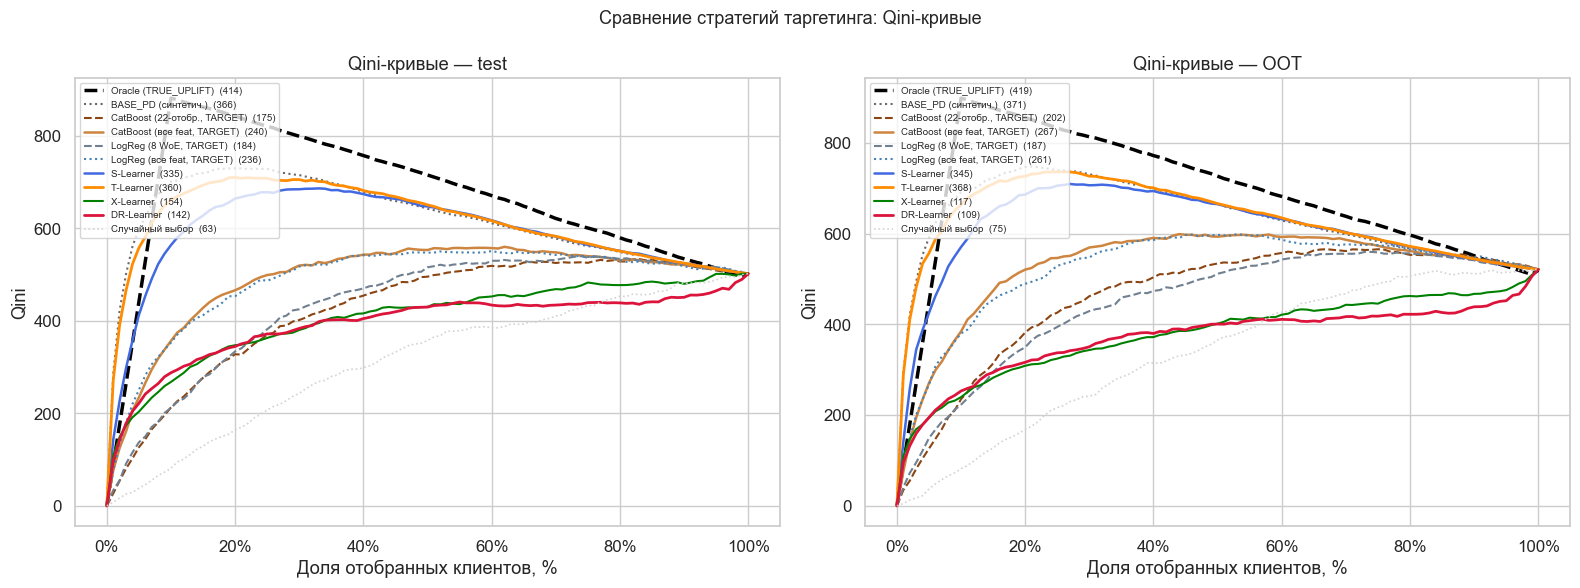

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_styles = [
    ('Logged-policy oracle',         'black',      '--', 2.5),
    ('Counterfactual oracle',        'darkviolet', '-.',  2.5),
    ('BASE_PD (синтетич.)',          'dimgray',    ':',  1.5),
    ('CatBoost (22-отобр., TARGET)', 'saddlebrown','--', 1.5),
    ('CatBoost (все feat, TARGET)',  'peru',       '-',  1.8),
    ('LogReg (8 WoE, TARGET)',       'slategray',  '--', 1.5),
    ('LogReg (все feat, TARGET)',    'steelblue',  ':',  1.5),
    ('S-Learner',                    'royalblue',  '-',  1.8),
    ('T-Learner',                    'darkorange', '-',  2.0),
    ('X-Learner',                    'green',      '-',  1.5),
    ('DR-Learner',                   'crimson',    '-',  2.0),
    ('Случайный выбор',              'lightgray',  ':',  1.2),
]

score_map_test = {
    **scores_baselines,
    'S-Learner':  score_s_test,
    'T-Learner':  score_t_test,
    'X-Learner':  score_x_test,
    'DR-Learner': score_dr_test,
}
score_map_oot = {
    **scores_baselines_oot,
    'S-Learner':  score_s_oot,
    'T-Learner':  score_t_oot,
    'X-Learner':  score_x_oot,
    'DR-Learner': score_dr_oot,
}

for ax, (y_arr, t_arr, sc_map, suffix) in zip(axes, [
    (y_test, t_test_bin, score_map_test, 'test'),
    (y_oot,  t_oot_bin,  score_map_oot,  'OOT'),
]):
    for label, color, ls, lw in plot_styles:
        if label not in sc_map:
            continue
        fracs, qini, _, auuc = compute_qini(y_arr, t_arr, sc_map[label])
        ax.plot(fracs * 100, qini, color=color, linestyle=ls, linewidth=lw,
                label=f'{label}  ({auuc:.0f})')
    ax.set_xlabel('Доля отобранных клиентов, %')
    ax.set_ylabel('Qini')
    ax.set_title(f'Qini-кривые — {suffix}')
    ax.legend(loc='upper left', fontsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.suptitle('Сравнение стратегий таргетинга: Qini-кривые', fontsize=13)
plt.tight_layout()
plt.show()

## 9.1. Бизнес-потенциал: текущая политика против counterfactual oracle

Оценивается **доля потенциального эффекта**, которую реализует текущая историческая политика банка.

| Концепция | Определение |
|---|---|
| **Текущая политика** | Исторически назначенные каналы; эффект = `TRUE_UPLIFT` (0 для control-группы) |
| **Logged-policy oracle** | Идеальный отбор клиентов внутри текущей политики на основе `TRUE_UPLIFT` |
| **Counterfactual oracle** | Оптимальный канал для **каждого** клиента; эффект = `ORACLE_TRUE_UPLIFT` |

**Метрика политической ценности** — среднее снижение вероятности дефолта на клиента в
генеральной совокупности:

$$V(\pi) = \mathbb{E}_x[\tau_{\pi(x)}(x)]$$

Клиент без коммуникации ($\pi(x) = \text{control}$) вносит нулевой вклад.

In [ ]:
# ====== Бизнес-потенциал ======
# channel_costs: условные единицы затрат на 1 контакт (масштаб: 1 у.е. = 0.001 PD)
_ch_costs = {'sms': 0.5, 'robot_call': 2.0, 'operator_call': 10.0, 'control': 0.0}
_cost_scale = 0.001

def _policy_value(df, uplift_col, comm_col=None):
    """Возвращает (gross, net) политическую ценность."""
    gross = df[uplift_col].mean()
    if comm_col and comm_col in df.columns:
        costs = df[comm_col].map(_ch_costs).fillna(0).values * _cost_scale
        net = (df[uplift_col].values - costs).mean()
    else:
        costs = df['COMMUNICATION'].map(_ch_costs).fillna(0).values * _cost_scale
        net = (df[uplift_col].values - costs).mean()
    return gross, net

for split, df_s in [('test', test), ('OOT', oot)]:
    if 'ORACLE_TRUE_UPLIFT' not in df_s.columns:
        print(f'{split}: ORACLE_TRUE_UPLIFT not found, skip'); continue

    v_cur_g,  v_cur_n  = _policy_value(df_s, 'TRUE_UPLIFT', 'COMMUNICATION')
    v_cf_g,   v_cf_n   = _policy_value(df_s, 'ORACLE_TRUE_UPLIFT',
                                        'ORACLE_COMMUNICATION' if 'ORACLE_COMMUNICATION' in df_s.columns else None)
    pct_g = v_cur_g / v_cf_g * 100 if v_cf_g != 0 else float('nan')
    pct_n = v_cur_n / v_cf_n * 100 if v_cf_n != 0 else float('nan')
    cr    = (df_s['COMMUNICATION'] != 'control').mean()

    print(f"{'='*55}")
    print(f"Сплит: {split}  |  Доля контактируемых: {cr:.1%}")
    print(f"{'Метрика':<40} {'Gross':>10} {'Net':>10}")
    print('-' * 62)
    print(f"{'Текущая политика':<40} {v_cur_g:>10.6f} {v_cur_n:>10.6f}")
    print(f"{'Counterfactual oracle':<40} {v_cf_g:>10.6f} {v_cf_n:>10.6f}")
    print(f"{'% реализованного потенциала':<40} {pct_g:>9.1f}% {pct_n:>9.1f}%")
    print()

print("Интерпретация: текущая политика реализует лишь малую долю потенциала CF oracle,")
print("т.к. ~90% клиентов не получают коммуникацию (control-группа).")

## 9.2. Статистическая устойчивость: paired bootstrap CI для AUUC

Одно точечное значение AUUC не позволяет судить об устойчивости превосходства одной модели над другой.
**Paired bootstrap** оценивает, является ли разница статистически надёжной.

**Процедура:**
1. На каждой из 2 000 bootstrap-итераций сэмплируем test-выборку **с возвращением**.
2. На **одной и той же** bootstrap-подвыборке считаем AUUC двух сравниваемых моделей.
3. Распределение разностей $\Delta \text{AUUC} = \text{AUUC}(A) - \text{AUUC}(B)$ даёт 95% CI.
4. Если CI не пересекает ноль — разница статистически устойчива.

In [ ]:
def _boot_auuc_ci(y, t, score, n_boot=2000, seed=RANDOM_SEED):
    """Bootstrap 95% CI для одиночного AUUC."""
    rng_b = np.random.RandomState(seed)
    n = len(y)
    vals = [compute_qini(y[idx_b], t[idx_b], score[idx_b])[3]
            for idx_b in (rng_b.choice(n, n, replace=True) for _ in range(n_boot))]
    arr = np.array(vals)
    return arr.mean(), tuple(np.percentile(arr, [2.5, 97.5]))


def _boot_diff_ci(y, t, sc_a, sc_b, n_boot=2000, seed=RANDOM_SEED):
    """Paired bootstrap 95% CI для AUUC(A) - AUUC(B)."""
    rng_b = np.random.RandomState(seed)
    n = len(y)
    diffs = []
    for _ in range(n_boot):
        ib = rng_b.choice(n, n, replace=True)
        diffs.append(compute_qini(y[ib], t[ib], sc_a[ib])[3]
                     - compute_qini(y[ib], t[ib], sc_b[ib])[3])
    arr = np.array(diffs)
    p = min(np.mean(arr <= 0), np.mean(arr >= 0)) * 2
    return arr.mean(), tuple(np.percentile(arr, [2.5, 97.5])), p


# --- Индивидуальные CI ---
_boot_models = {
    'Logged-policy oracle': scores_baselines['Logged-policy oracle'],
    'CatBoost (все feat)':  cb_all_score_test,
    'S-Learner':            score_s_test,
    'T-Learner':            score_t_test,
    'X-Learner':            score_x_test,
    'DR-Learner':           score_dr_test,
}

print('Bootstrap 95% CI для AUUC (test, n_boot=2 000)\n')
print(f"{'Модель':<35} {'AUUC':>8}  {'95% CI':>22}")
print('-' * 70)
_ci_store = {}
for name, sc in _boot_models.items():
    mean_a, (lo, hi) = _boot_auuc_ci(y_test, t_test_bin, sc)
    _ci_store[name] = (mean_a, lo, hi)
    print(f"{name:<35} {mean_a:>8.5f}  [{lo:>8.5f}, {hi:>8.5f}]")

# --- Paired diff: лучший uplift vs CatBoost (все feat) ---
_uplift_names = ['S-Learner', 'T-Learner', 'X-Learner', 'DR-Learner']
_best_u = max(_uplift_names, key=lambda m: _ci_store[m][0])
_sc_best_u = _boot_models[_best_u]

delta, (dlo, dhi), pv = _boot_diff_ci(y_test, t_test_bin, _sc_best_u, cb_all_score_test)
verdict = 'УСТОЙЧИВА (p<0.05)' if pv < 0.05 else 'не значима (p>=0.05)'
print(f"\nPaired bootstrap: {_best_u} vs CatBoost (все feat)")
print(f"ΔAUUC = {delta:+.5f}   95% CI = [{dlo:+.5f}, {dhi:+.5f}]   p ≈ {pv:.3f}")
print(f"Вывод: разница {verdict}")

## 10. Верификация через истинный uplift (ground truth)

### Методологическая ценность

В реальных данных $\tau(x)$ никогда не наблюдается для отдельного клиента. В нашем синтетическом датасете `TRUE_UPLIFT` известен для каждого наблюдения, что позволяет применить **«золотой стандарт»** uplift-валидации:

| Метрика | Формула | Что показывает |
|---|---|---|
| **RMSE** | $\sqrt{\frac{1}{n}\sum_i(\hat{\tau}_i - \tau_i)^2}$ | Точность численной оценки эффекта |
| **Spearman $\rho$** | $\rho(\hat{\tau}, \tau)$ | Правильность ранжирования по силе эффекта |
| **Calibration plot** | $\mathbb{E}[\tau \mid \hat{\tau} \in \text{дециль}_k]$ vs. $\bar{\hat{\tau}}_k$ | Систематическое перео- / недооценивание |

### Calibration plot — как читать

Клиенты разбиваются на 10 децилей по предсказанному $\hat{\tau}(x)$. Для каждого дециля вычисляется среднее предсказанное и среднее истинное значение:

- **Точки на красной диагонали** ($y = x$) — идеальная калибровка.
- **Точки выше диагонали** — модель переоценивает эффект (оптимистична).
- **Точки ниже диагонали** — модель недооценивает эффект.
- **Горизонтальная зависимость** (точки вблизи одной горизонтали) — модель не различает клиентов по силе эффекта: ранжирующая способность отсутствует.

**RMSE vs. Spearman $\rho$:** низкий RMSE с низким $|\rho|$ означает, что модель предсказывает близкие к истинным численные значения эффекта в среднем, но не ранжирует клиентов правильно — для CRM-таргетинга важен именно $\rho$, а не RMSE.

In [32]:
# RMSE и Spearman rho к TRUE_UPLIFT
model_uplift_preds = {
    'S-Learner':            uplift_s_test['best'],
    'T-Learner':            uplift_t_test['best'],
    'X-Learner':            uplift_x_test,
    'DR-Learner':           uplift_dr_test,
    'Risk-based (BASE_PD)': test['BASE_PD'].values,
}

true_uplift = test['TRUE_UPLIFT'].values

print(f'{'Модель':<22} {'RMSE':>8} {'Spearman rho':>14} {'p-value':>10}')
print('-' * 58)
for name, pred in model_uplift_preds.items():
    rmse = np.sqrt(np.mean((pred - true_uplift) ** 2))
    sp_rho, sp_p = stats.spearmanr(pred, true_uplift)
    sig = '**' if sp_p < 0.01 else ('*' if sp_p < 0.05 else '')
    print(f'{name:<22} {rmse:>8.5f} {sp_rho:>14.4f} {sp_p:>10.4f} {sig}')
print('* p<0.05, ** p<0.01')


Модель                     RMSE   Spearman rho    p-value
----------------------------------------------------------
S-Learner               0.04985         0.2000     0.0000 **
T-Learner               0.13532         0.2052     0.0000 **
X-Learner               0.02161        -0.0023     0.5644 
DR-Learner              0.02614         0.0066     0.1015 
Risk-based (BASE_PD)    0.15870        -0.2174     0.0000 **
* p<0.05, ** p<0.01


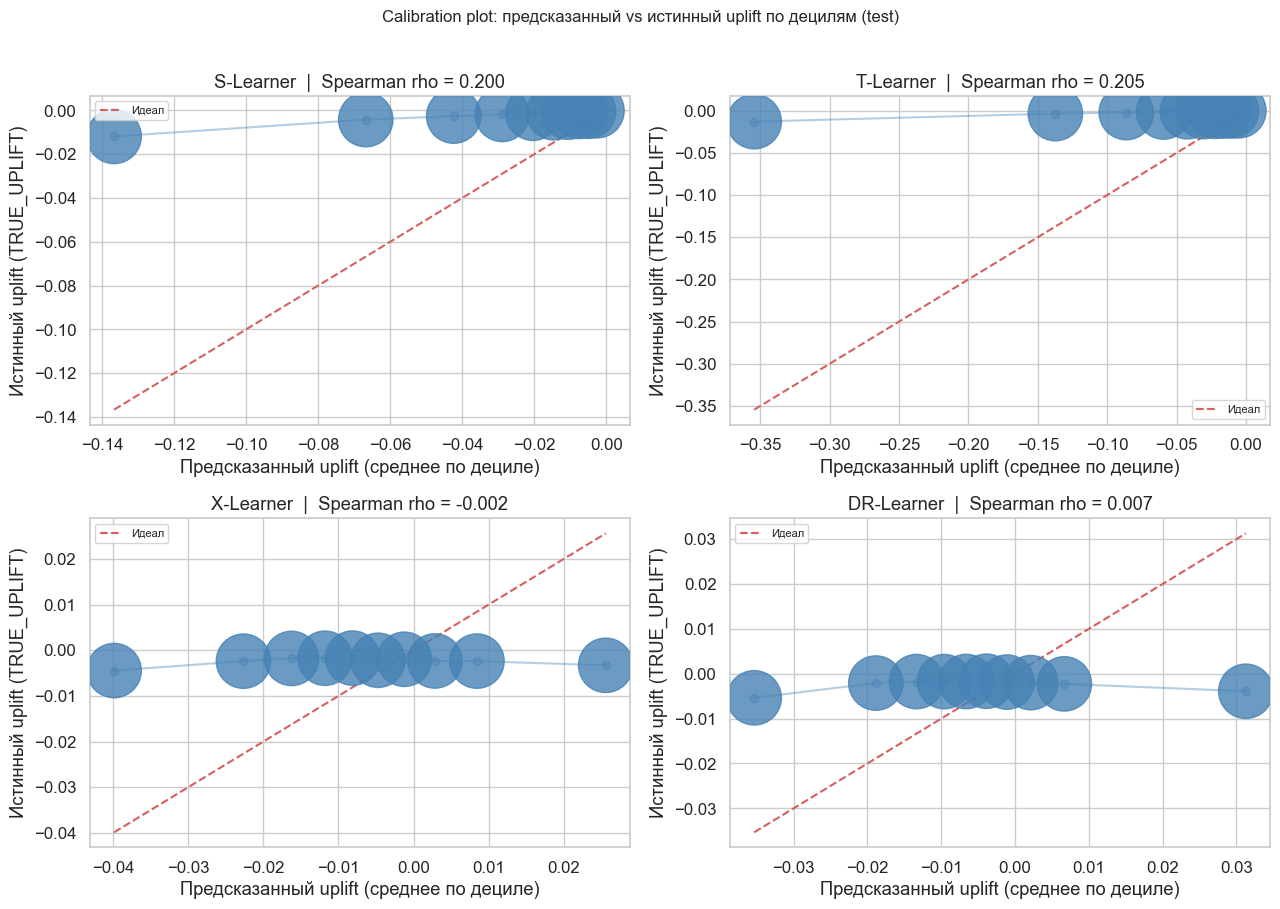

Как читать: точки на красной диагонали = идеальная калибровка.
Выше диагонали = модель переоценивает эффект. Ниже = недооценивает.


In [33]:
# Calibration plot: предсказанный vs истинный uplift по децилям
uplift_models_cal = {k: v for k, v in model_uplift_preds.items()
                      if k != 'Risk-based (BASE_PD)'}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, uplift_models_cal.items()):
    df_cal = pd.DataFrame({'pred': pred, 'true': true_uplift})
    df_cal['decile'] = pd.qcut(df_cal['pred'], q=10, labels=False, duplicates='drop')
    cal = df_cal.groupby('decile').agg(
        pred_mean=('pred', 'mean'),
        true_mean=('true', 'mean'),
        count=('pred', 'count'),
    ).reset_index()

    ax.scatter(cal['pred_mean'], cal['true_mean'],
               s=cal['count'] / 4, alpha=0.8, color='steelblue', zorder=5)
    ax.plot(cal['pred_mean'], cal['true_mean'], '-o', color='steelblue', alpha=0.4)

    lo = min(cal['pred_mean'].min(), cal['true_mean'].min())
    hi = max(cal['pred_mean'].max(), cal['true_mean'].max())
    ax.plot([lo, hi], [lo, hi], 'r--', label='Идеал')

    sp_rho, _ = stats.spearmanr(pred, true_uplift)
    ax.set_title(f'{name}  |  Spearman rho = {sp_rho:.3f}')
    ax.set_xlabel('Предсказанный uplift (среднее по дециле)')
    ax.set_ylabel('Истинный uplift (TRUE_UPLIFT)')
    ax.legend(fontsize=8)

plt.suptitle('Calibration plot: предсказанный vs истинный uplift по децилям (test)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print('Как читать: точки на красной диагонали = идеальная калибровка.')
print('Выше диагонали = модель переоценивает эффект. Ниже = недооценивает.')


In [34]:
scores_to_save = pd.DataFrame({
    'split':          ['test'] * len(y_test) + ['oot'] * len(y_oot),
    'y':              np.concatenate([y_test, y_oot]),
    'treatment_bin':  np.concatenate([t_test_bin, t_oot_bin]),
    'COMMUNICATION':  np.concatenate([T_test, T_oot]),
    'BASE_PD':        np.concatenate([test['BASE_PD'].values,  oot['BASE_PD'].values]),
    'TRUE_UPLIFT':    np.concatenate([test['TRUE_UPLIFT'].values, oot['TRUE_UPLIFT'].values]),
    'RISK_SEGMENT':   np.concatenate([test['RISK_SEGMENT'].values, oot['RISK_SEGMENT'].values]),
    # Risk-baseline scores
    'score_cb_saved': np.concatenate([cb_saved_score_test, cb_saved_score_oot]),
    'score_cb_all':   np.concatenate([cb_all_score_test,   cb_all_score_oot]),
    'score_lr_saved': np.concatenate([lr_saved_score_test, lr_saved_score_oot]),
    'score_lr_all':   np.concatenate([lr_all_score_test,   lr_all_score_oot]),
    # Uplift scores
    'score_s':        np.concatenate([score_s_test,  score_s_oot]),
    'score_t':        np.concatenate([score_t_test,  score_t_oot]),
    'score_x':        np.concatenate([score_x_test,  score_x_oot]),
    'score_dr':       np.concatenate([score_dr_test, score_dr_oot]),
    # Per-channel S-Learner
    'uplift_s_sms':      np.concatenate([uplift_s_test['sms'],          uplift_s_oot['sms']]),
    'uplift_s_robot':    np.concatenate([uplift_s_test['robot_call'],   uplift_s_oot['robot_call']]),
    'uplift_s_operator': np.concatenate([uplift_s_test['operator_call'],uplift_s_oot['operator_call']]),
    # Per-channel T-Learner
    'uplift_t_sms':      np.concatenate([uplift_t_test['sms'],          uplift_t_oot['sms']]),
    'uplift_t_robot':    np.concatenate([uplift_t_test['robot_call'],   uplift_t_oot['robot_call']]),
    'uplift_t_operator': np.concatenate([uplift_t_test['operator_call'],uplift_t_oot['operator_call']]),
})
scores_to_save.to_csv('data/processed/uplift_scores.csv', index=False)
print(f"Скоры сохранены: {len(scores_to_save):,} строк × {len(scores_to_save.columns)} колонок")

Скоры сохранены: 123,005 строк × 21 колонок


---

## 12. Зависимость качества от объёма обучающих данных

### Методология

Каждая модель переобучается на **подвыборках** обучающего набора фиксированного размера;
качество оценивается на неизменном тестовом наборе (61 502 наблюдений).
Для uplift-моделей основная метрика — **AUUC** (Qini); дополнительно отслеживается
**Spearman $\rho$** с `TRUE_UPLIFT` как прямое свидетельство каузальной точности.

| Параметр | Значение |
|---|---|
| Доли train | 5%, 10%, 20%, 35%, 50%, 70%, 100% |
| DR-Learner CV | 3-fold (упрощённый, 100 итер. nuisance) |
| Оценочный набор | фиксированный test (61 502) |

**Что ожидаем увидеть:**
- Risk-based модели выходят на плато раньше (нет необходимости в контрфактуальных оценках)
- T-Learner при малых N нестабилен из-за малочисленных SMS-группы (~1.7%)
- DR-Learner требует наибольшего объёма для стабилизации OOF-оценок
- При достаточном N разрыв между лучшим uplift-методом и risk-based может сократиться

In [35]:
fractions_lc = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.35, 0.5, 0.7, 1.0]
MIN_CH_SAMPLES = 150
lc_rows = []

print(f'{"frac":>5} {"N":>7} | {"CB-risk":>8} {"LR-risk":>8} {"S-Lrn":>8} {"T-Lrn":>8} {"DR-Lrn":>8}')
print('-' * 65)

for frac in fractions_lc:
    if frac < 1.0:
        from sklearn.model_selection import train_test_split as _tts
        idx_f, _ = _tts(np.arange(len(X_train)), train_size=frac,
                         stratify=t_train_bin, random_state=RANDOM_SEED)
        idx_f = sorted(idx_f)
    else:
        idx_f = np.arange(len(X_train))

    Xf      = X_train.iloc[idx_f].reset_index(drop=True)
    yf      = y_train[idx_f]
    Tf      = T_train[idx_f]
    tf_bin  = t_train_bin[idx_f]
    y_orig_f = train.iloc[idx_f]['TARGET'].values
    row = {'frac': frac, 'n': len(idx_f)}

    # ── CatBoost-risk (все feat + categoricals) ────────────────────────────
    Xf_cba = pd.concat([
        Xf,
        train.iloc[idx_f][cat_cols_all].fillna('missing').astype(str).reset_index(drop=True)
    ], axis=1)
    cb_lc = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6,
                                cat_features=cat_idx_all,
                                random_seed=RANDOM_SEED, verbose=0)
    cb_lc.fit(Xf_cba, y_orig_f)
    _, _, _, auuc = compute_qini(y_test, t_test_bin, cb_lc.predict_proba(X_test_cba)[:, 1])
    rho, _ = stats.spearmanr(cb_lc.predict_proba(X_test_cba)[:, 1], true_uplift_test)
    row['CatBoost-risk AUUC'] = auuc;  row['CatBoost-risk rho'] = rho

    # ── LogReg-risk (все числовые feat) ────────────────────────────────────
    lr_lc = Pipeline([('scaler', StandardScaler()),
                       ('lr', LogisticRegression(C=0.1, max_iter=500,
                                                  random_state=RANDOM_SEED))])
    lr_lc.fit(Xf, y_orig_f)
    _, _, _, auuc = compute_qini(y_test, t_test_bin, lr_lc.predict_proba(X_test)[:, 1])
    rho, _ = stats.spearmanr(lr_lc.predict_proba(X_test)[:, 1], true_uplift_test)
    row['LogReg-risk AUUC'] = auuc;  row['LogReg-risk rho'] = rho

    # ── S-Learner ─────────────────────────────────────────────────────────
    enc_lc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    enc_lc.fit(Tf.reshape(-1, 1))
    Xf_s = add_treatment_ohe(Xf, Tf, enc_lc)
    s_lc = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6,
                               random_seed=RANDOM_SEED, verbose=0)
    s_lc.fit(Xf_s, yf)
    upl_s_lc = s_learner_uplift_per_channel(s_lc, X_test, enc_lc, channels_list)
    _, _, _, auuc = compute_qini(y_test, t_test_bin, -upl_s_lc['best'])
    rho, _ = stats.spearmanr(upl_s_lc['best'], true_uplift_test)
    row['S-Learner AUUC'] = auuc;  row['S-Learner rho'] = rho

    # ── T-Learner ─────────────────────────────────────────────────────────
    t_lc = {}; ok = True
    for ch in ['control'] + channels_list:
        mask_ch = Tf == ch
        if mask_ch.sum() < MIN_CH_SAMPLES:
            ok = False; break
        m = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=5,
                                random_seed=RANDOM_SEED, verbose=0)
        m.fit(Xf[mask_ch].reset_index(drop=True), yf[mask_ch])
        t_lc[ch] = m
    if ok:
        upl_t_lc = t_learner_uplift(t_lc, X_test, channels_list)
        _, _, _, auuc = compute_qini(y_test, t_test_bin, -upl_t_lc['best'])
        rho, _ = stats.spearmanr(upl_t_lc['best'], true_uplift_test)
        row['T-Learner AUUC'] = auuc;  row['T-Learner rho'] = rho
    else:
        row['T-Learner AUUC'] = float('nan');  row['T-Learner rho'] = float('nan')

    # ── DR-Learner (упрощённый: 3-fold, 100 iter nuisance) ────────────────
    kf3 = KFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
    Xf_arr = Xf.values
    mu1_o = np.zeros(len(Xf_arr)); mu0_o = np.zeros(len(Xf_arr)); e_o = np.zeros(len(Xf_arr))
    for _, (idx_tr, idx_val) in enumerate(kf3.split(Xf_arr)):
        Xk, Xv = Xf_arr[idx_tr], Xf_arr[idx_val]
        yk, tk = yf[idx_tr], tf_bin[idx_tr]
        mu_k = CatBoostClassifier(iterations=100, learning_rate=0.05, depth=4,
                                   random_seed=RANDOM_SEED, verbose=0)
        mu_k.fit(np.column_stack([Xk, tk]), yk)
        mu1_o[idx_val] = mu_k.predict_proba(np.column_stack([Xv, np.ones(len(Xv))]))[:, 1]
        mu0_o[idx_val] = mu_k.predict_proba(np.column_stack([Xv, np.zeros(len(Xv))]))[:, 1]
        e_k = CatBoostClassifier(iterations=50, learning_rate=0.05, depth=3,
                                  random_seed=RANDOM_SEED, verbose=0)
        e_k.fit(Xk, tk)
        e_o[idx_val] = e_k.predict_proba(Xv)[:, 1]
    e_cl = np.clip(e_o, 0.05, 0.95)
    dr_ps = (mu1_o - mu0_o) + (tf_bin - e_cl) / (e_cl * (1 - e_cl)) * (yf - (tf_bin * mu1_o + (1 - tf_bin) * mu0_o))
    dr_lc = CatBoostRegressor(iterations=200, learning_rate=0.05, depth=5,
                               random_seed=RANDOM_SEED, verbose=0)
    dr_lc.fit(Xf_arr, dr_ps)
    upl_dr_lc = dr_lc.predict(X_test.values)
    _, _, _, auuc = compute_qini(y_test, t_test_bin, -upl_dr_lc)
    rho, _ = stats.spearmanr(upl_dr_lc, true_uplift_test)
    row['DR-Learner AUUC'] = auuc;  row['DR-Learner rho'] = rho

    lc_rows.append(row)
    print(f"{frac:5.0%} {len(idx_f):>7,} | "
          f"{row['CatBoost-risk AUUC']:>8.1f} "
          f"{row['LogReg-risk AUUC']:>8.1f} "
          f"{row.get('S-Learner AUUC', float('nan')):>8.1f} "
          f"{row.get('T-Learner AUUC', float('nan')):>8.1f} "
          f"{row.get('DR-Learner AUUC', float('nan')):>8.1f}")

lc_df = pd.DataFrame(lc_rows).set_index('n')
print('\nГотово.')

 frac       N |  CB-risk  LR-risk    S-Lrn    T-Lrn   DR-Lrn
-----------------------------------------------------------------
   0%     922 |    187.0     21.1    135.2      nan    -65.1
   1%   1,845 |    180.0     47.1    -32.5      nan    -77.2
   2%   3,690 |    183.0     70.3    260.1      nan    -21.8
   5%   9,225 |    210.3    103.0    338.5    353.3     30.3
  10%  18,450 |    221.4    126.7    328.9    356.3      0.7
  20%  36,901 |    228.6    150.2    332.4    357.4    -42.7
  35%  64,577 |    237.2    158.8    334.1    358.7    -30.0
  50%  92,253 |    234.8    171.4    335.0    359.6    -45.6
  70% 129,154 |    237.8    174.7    338.1    358.9    -41.7
 100% 184,506 |    240.5    179.1    336.7    360.4    -69.1

Готово.


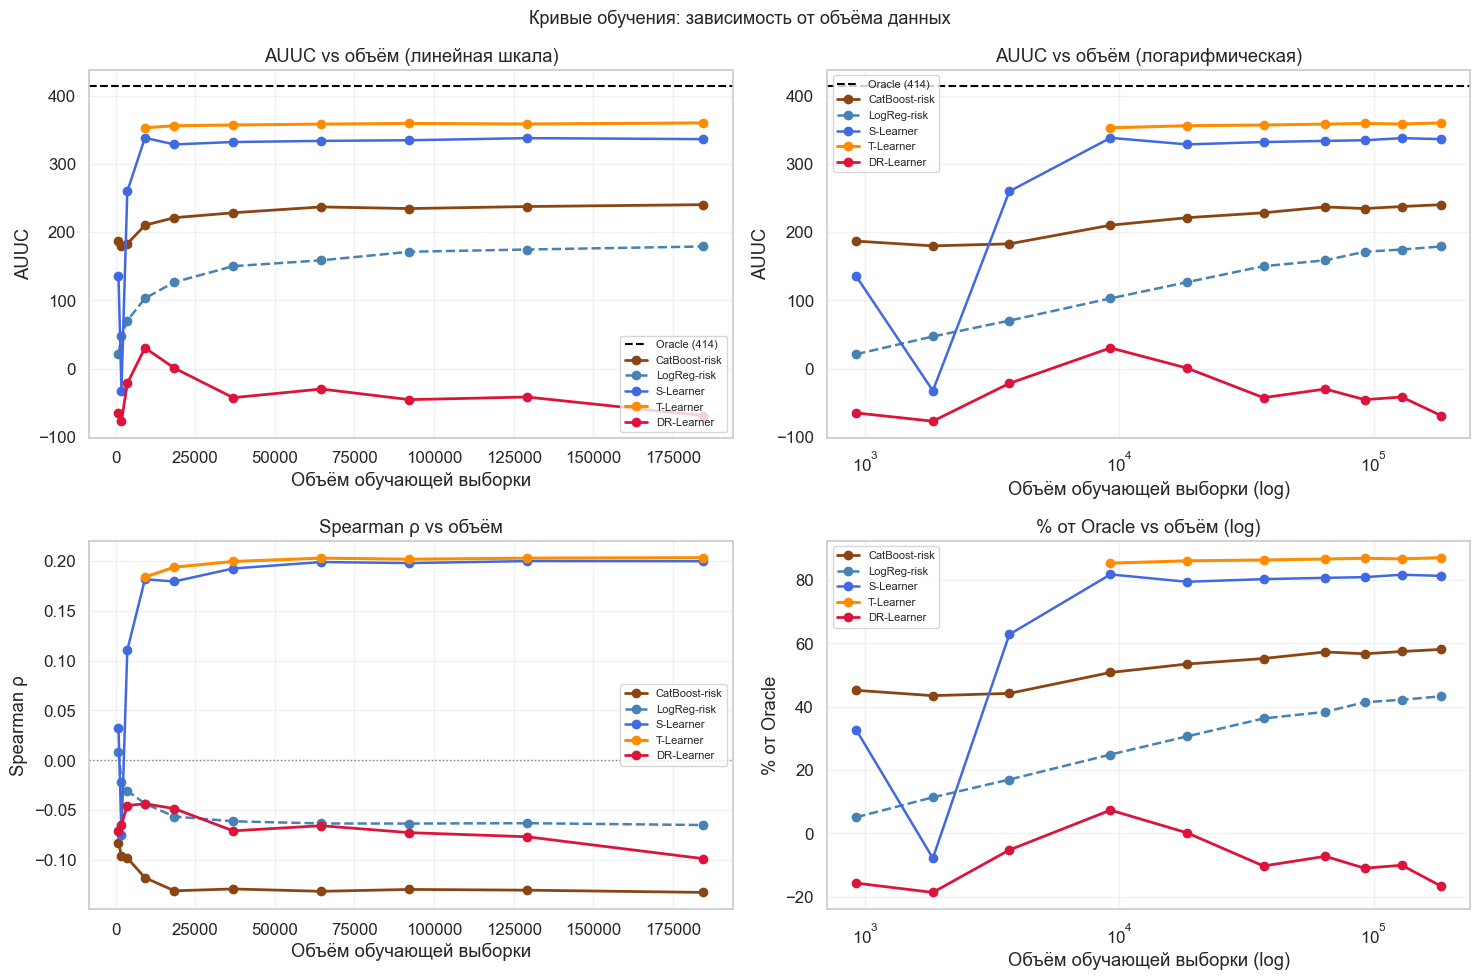


Итоговые значения при 100% train:
Модель                        AUUC   % Oracle   Spearman rho
--------------------------------------------------------------
CatBoost-risk                240.5       58.1%        -0.1323
LogReg-risk                  179.1       43.3%        -0.0648
S-Learner                    336.7       81.3%         0.1996
T-Learner                    360.4       87.1%         0.2032
DR-Learner                   -69.1      -16.7%        -0.0985


In [36]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

_styles = {
    'CatBoost-risk': ('saddlebrown', '-',  2.0),
    'LogReg-risk':   ('steelblue',   '--', 1.8),
    'S-Learner':     ('royalblue',   '-',  1.8),
    'T-Learner':     ('darkorange',  '-',  2.2),
    'DR-Learner':    ('crimson',     '-',  2.0),
}
oracle_auuc_lc = baseline_auuc['Logged-policy oracle']

for ax_idx, (ax, ylabel, col_suffix, title, log_x) in enumerate([
    (axes[0,0], 'AUUC',        'AUUC', 'AUUC vs объём (линейная шкала)',     False),
    (axes[0,1], 'AUUC',        'AUUC', 'AUUC vs объём (логарифмическая)',     True),
    (axes[1,0], 'Spearman ρ',  'rho',  'Spearman ρ vs объём',                False),
    (axes[1,1], '% от Oracle', 'AUUC', '% от Oracle vs объём (log)',          True),
]):
    if col_suffix == 'AUUC' and ylabel == 'AUUC':
        ax.axhline(oracle_auuc_lc, color='black', ls='--', lw=1.5,
                   label=f'Oracle ({oracle_auuc_lc:.0f})')
    if col_suffix == 'rho':
        ax.axhline(0, color='gray', ls=':', lw=1)

    for model, (color, ls, lw) in _styles.items():
        col = f'{model} {col_suffix}'
        if col not in lc_df.columns:
            continue
        vals = lc_df[col]
        if ylabel == '% от Oracle':
            vals = vals / oracle_auuc_lc * 100
        ax.plot(lc_df.index, vals, f'o{ls}', color=color, lw=lw, label=model)

    if log_x:
        ax.set_xscale('log')
    ax.set_xlabel('Объём обучающей выборки' + (' (log)' if log_x else ''))
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.suptitle('Кривые обучения: зависимость от объёма данных', fontsize=13)
plt.tight_layout()
plt.show()

# Итоговая таблица
print('\nИтоговые значения при 100% train:')
full_row = lc_df.iloc[-1]
print(f'{"Модель":<25} {"AUUC":>8} {"% Oracle":>10} {"Spearman rho":>14}')
print('-' * 62)
for model in _styles:
    auuc_v = full_row.get(f'{model} AUUC', float('nan'))
    rho_v  = full_row.get(f'{model} rho', float('nan'))
    pct    = auuc_v / oracle_auuc_lc * 100 if not pd.isna(auuc_v) else float('nan')
    print(f'{model:<25} {auuc_v:>8.1f} {pct:>10.1f}% {rho_v:>14.4f}')

---

## 13. Risk-Effect Alignment Sweep: анализ условий применимости uplift-моделей

### Методология эксперимента

В разделе 8.1 зафиксировано, что текущий DGP **aligned**: эффект коммуникации пропорционален
BASE\_PD, что структурно выгодно для риск-моделей. Данный эксперимент исследует, как меняется
относительное качество подходов при изменении этого свойства.

**Принцип:** без изменения признаков, модели рисков и train/test/OOT-разбивки, меняется только
корреляция между BASE\_PD и TRUE\_UPLIFT внутри каждого канала.

#### Четыре alignment-сценария

| Сценарий | Описание | Ожидание |
|---|---|---|
| **aligned** | Текущий DGP: `τ ∝ BASE_PD` | Risk-модели конкурентны |
| **weakly\_aligned** | 50% исходного + 50% перемешанного эффекта | Преимущество риска снижается |
| **orthogonal** | Эффекты перемешаны внутри канала (τ ⊥ BASE\_PD) | Риск-модели теряют преимущество |
| **mid\_risk** | Максимум эффекта у клиентов среднего риска | Риск-модели могут навредить |

#### Common Random Numbers (CRN)

Бинарный исход генерируется через **единый** вектор равномерных случайных чисел `u`:
```
TARGET_after_s[i] = 1  если  u[i] < PD_after_s[i]
```
Один и тот же `u` используется во всех сценариях — различия в AUUC вызваны только изменением
эффекта, а не новой случайной реализацией Бернулли.

#### Что переобучается, что остаётся

| Компонент | Действие |
|---|---|
| Признаки клиентов (X) | **Не меняются** |
| Risk-модели (BASE\_PD, CatBoost) | **Не переобучаются** — они предсказывают TARGET, а не эффект |
| Uplift-модели (S/T-Learner) | **Переобучаются** на сценарий-специфичном `TARGET_after_s` |

In [ ]:
# ====== Common Random Numbers — единый вектор для всех сценариев ======
_rng_crn = np.random.RandomState(RANDOM_SEED + 200)
_u_train  = _rng_crn.uniform(size=len(train))
_u_test   = _rng_crn.uniform(size=len(test))

# ====== Scenario generators (работают со split-датафреймом) ======

def _sw_aligned(df, **kw):
    """Текущий DGP: TRUE_UPLIFT без изменений."""
    return df['TRUE_UPLIFT'].values.copy()


def _sw_weakly(df, alpha=0.5, seed=RANDOM_SEED + 201, **kw):
    """50% исходного + 50% перемешанного внутри канала."""
    rng_s = np.random.RandomState(seed)
    tu = df['TRUE_UPLIFT'].values.copy()
    for ch in ['sms', 'robot_call', 'operator_call']:
        mask = (df['COMMUNICATION'] == ch).values
        if mask.sum() < 2:
            continue
        n_ch  = mask.sum()
        perm  = rng_s.permutation(n_ch)
        idx   = np.where(mask)[0]
        tu[idx] = alpha * tu[idx] + (1 - alpha) * tu[idx][perm]
    return tu


def _sw_orthogonal(df, seed=RANDOM_SEED + 202, **kw):
    """Полное перемешивание TRUE_UPLIFT внутри каждого канала."""
    rng_s = np.random.RandomState(seed)
    tu = df['TRUE_UPLIFT'].values.copy()
    for ch in ['sms', 'robot_call', 'operator_call']:
        mask = (df['COMMUNICATION'] == ch).values
        if mask.sum() < 2:
            continue
        idx       = np.where(mask)[0]
        perm      = rng_s.permutation(len(idx))
        tu[idx]   = tu[idx][perm]
    return tu


def _sw_mid_risk(df, seed=RANDOM_SEED + 203, **kw):
    """Сильнейшие эффекты — клиентам ближайшим к медиане BASE_PD канала."""
    tu  = df['TRUE_UPLIFT'].values.copy()
    bp  = df['BASE_PD'].values
    for ch in ['sms', 'robot_call', 'operator_call']:
        mask = (df['COMMUNICATION'] == ch).values
        if mask.sum() < 10:
            continue
        idx      = np.where(mask)[0]
        eff_ch   = tu[idx]
        bp_ch    = bp[idx]

        # Сортируем эффекты по убыванию силы (самые отрицательные — первые)
        eff_order  = np.argsort(eff_ch)          # ascending: [0] = самый отрицательный

        # Сортируем клиентов: ближайшие к медиане BASE_PD канала — первые
        bp_med     = np.median(bp_ch)
        dist       = np.abs(bp_ch - bp_med)
        client_order = np.argsort(dist)          # [0] = ближе всего к медиане

        # Присваиваем: клиент с позиции i в client_order получает эффект с позиции i в eff_order
        new_eff              = np.empty(len(idx))
        new_eff[client_order] = eff_ch[eff_order]
        tu[idx]               = new_eff
    return tu


_scenarios = {
    'aligned':        _sw_aligned,
    'weakly_aligned': _sw_weakly,
    'orthogonal':     _sw_orthogonal,
    'mid_risk':       _sw_mid_risk,
}

print('Сценарии alignment sweep:', list(_scenarios.keys()))
print(f'CRN: u_train shape={_u_train.shape}, u_test shape={_u_test.shape}')

In [ ]:
# ====== Alignment Sweep: обучение и оценка ======
# Для каждого сценария: лёгкие S-Learner и T-Learner (300 итераций),
# плюс неизменные риск-скоры BASE_PD и CatBoost.

_sweep_rows = []

for _sc_name, _gen_fn in _scenarios.items():
    print(f"\n--- Сценарий: {_sc_name} ---")

    # 1. Новый TRUE_UPLIFT для train и test
    _tu_tr = _gen_fn(train)
    _tu_te = _gen_fn(test)

    # 2. PD_after с клиппингом
    _raw_tr = train['BASE_PD'].values + _tu_tr
    _raw_te = test['BASE_PD'].values  + _tu_te
    _pd_tr  = np.clip(_raw_tr, 0.001, 0.999)
    _pd_te  = np.clip(_raw_te, 0.001, 0.999)

    _clip_tr = np.mean((_raw_tr < 0.001) | (_raw_tr > 0.999))
    _clip_te = np.mean((_raw_te < 0.001) | (_raw_te > 0.999))

    _realized_tr = _pd_tr - train['BASE_PD'].values
    _realized_te = _pd_te - test['BASE_PD'].values

    print(f"  clip_rate: train={_clip_tr:.2%}  test={_clip_te:.2%}")
    if _clip_te > 0.05:
        print("  ВНИМАНИЕ: clip_rate > 5%, сценарий искажён")

    # 3. Новые binary targets через CRN
    _y_tr_s = (_u_train < _pd_tr).astype(int)
    _y_te_s = (_u_test  < _pd_te).astype(int)
    print(f"  default rate: train={_y_tr_s.mean():.3%}  test={_y_te_s.mean():.3%}")

    # 4. S-Learner (лёгкий)
    _s_sw = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=5,
                                random_seed=RANDOM_SEED, verbose=0)
    _s_sw.fit(X_train_s, _y_tr_s)
    _upl_s_sw   = s_learner_uplift_per_channel(_s_sw, X_test, comm_encoder, channels_list)
    _score_s_sw = -_upl_s_sw['best']
    print(f"  S-Learner trained")

    # 5. T-Learner (лёгкий)
    _t_sw = {}
    for _ch in ['control'] + channels_list:
        _msk = T_train == _ch
        _m   = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=5,
                                   random_seed=RANDOM_SEED, verbose=0)
        _m.fit(X_train[_msk], _y_tr_s[_msk])
        _t_sw[_ch] = _m
    _upl_t_sw   = t_learner_uplift(_t_sw, X_test, channels_list)
    _score_t_sw = -_upl_t_sw['best']
    print(f"  T-Learner trained")

    # 6. Oracle AUUC для этого сценария (теоретический потолок)
    _oracle_auuc_sc = compute_qini(_y_te_s, t_test_bin, -_realized_te)[3]

    # 7. Записываем AUUC для всех моделей
    _models_sc = {
        'Logged-policy oracle': -_realized_te,
        'BASE_PD':              test['BASE_PD'].values,
        'CatBoost-risk':        cb_all_score_test,
        'S-Learner':            _score_s_sw,
        'T-Learner':            _score_t_sw,
    }
    for _mname, _sc in _models_sc.items():
        _auuc = compute_qini(_y_te_s, t_test_bin, _sc)[3]
        _pct  = _auuc / _oracle_auuc_sc * 100 if _oracle_auuc_sc != 0 else float('nan')
        _sweep_rows.append({
            'Сценарий':   _sc_name,
            'Модель':     _mname,
            'AUUC':       _auuc,
            '% Oracle':   _pct,
            'clip_rate':  _clip_te,
        })
        print(f"  {_mname:<28} AUUC={_auuc:.5f}  % Oracle={_pct:.1f}%")

print("\n=== Sweep завершён ===")

In [ ]:
# ====== Таблица: AUUC по сценариям ======
import warnings; warnings.filterwarnings('ignore')

_df_sw = pd.DataFrame(_sweep_rows)

# Pivot: строки = Модель, колонки = Сценарий
for _metric in ['AUUC', '% Oracle']:
    _piv = _df_sw.pivot_table(index='Модель', columns='Сценарий',
                               values=_metric, aggfunc='mean')
    _col_order = ['aligned', 'weakly_aligned', 'orthogonal', 'mid_risk']
    _col_order = [c for c in _col_order if c in _piv.columns]
    _piv = _piv[_col_order]

    # Порядок строк
    _row_order = ['Logged-policy oracle', 'CatBoost-risk', 'BASE_PD',
                  'S-Learner', 'T-Learner']
    _piv = _piv.reindex([r for r in _row_order if r in _piv.index])

    print(f"\n=== {_metric} по сценариям ===")
    fmt = '.5f' if _metric == 'AUUC' else '.1f'
    print(_piv.to_string(float_format=lambda x: f'{x:{fmt}}'))

# Clip rates
_cr = _df_sw.groupby('Сценарий')['clip_rate'].first()
print(f"\n=== clip_rate (test) ===")
for _sc, _cr_v in _cr.items():
    print(f"  {_sc:<20} {_cr_v:.3%}")

In [ ]:
# ====== График: AUUC vs Сценарий ======
_df_sw2 = pd.DataFrame(_sweep_rows)
_df_sw2 = _df_sw2[_df_sw2['Модель'] != 'Logged-policy oracle']

_sc_order = ['aligned', 'weakly_aligned', 'orthogonal', 'mid_risk']
_sc_labels = ['Aligned', 'Weakly
Aligned', 'Orthogonal', 'Mid-Risk']

_model_styles = {
    'BASE_PD':       ('dimgray',    'o-',  1.8),
    'CatBoost-risk': ('saddlebrown','s-',  2.0),
    'S-Learner':     ('royalblue',  '^--', 1.8),
    'T-Learner':     ('darkorange', 'D--', 2.0),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['AUUC', '% Oracle']):
    for mname, (color, marker, lw) in _model_styles.items():
        vals = []
        for sc in _sc_order:
            row = _df_sw2[(_df_sw2['Модель'] == mname) & (_df_sw2['Сценарий'] == sc)]
            vals.append(row[metric].values[0] if len(row) > 0 else float('nan'))
        ax.plot(_sc_labels, vals, marker[1:], marker=marker[0], color=color,
                linewidth=lw, label=mname, markersize=7)

    # Oracle line
    oracle_vals = []
    for sc in _sc_order:
        row = pd.DataFrame(_sweep_rows)
        row = row[(row['Модель'] == 'Logged-policy oracle') & (row['Сценарий'] == sc)]
        oracle_vals.append(row[metric].values[0] if len(row) > 0 else float('nan'))
    ax.plot(_sc_labels, oracle_vals, 'k--', linewidth=2, label='Oracle', alpha=0.6)

    ax.set_xlabel('Alignment сценарий')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} по alignment-сценариям')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Alignment Sweep: как меняется качество при разной связи риска и эффекта',
             fontsize=12)
plt.tight_layout()
plt.show()

print("\nКлючевой вывод:")
print("  Чем слабее связь риск → эффект, тем важнее uplift-моделирование.")
print("  В aligned сценарии риск-модели конкурентны структурно, а не содержательно.")

### 13.1 Интерпретация результатов alignment sweep

Эксперимент проверяет **граничные условия применимости** каждого подхода, без изменения
исходных данных — только структура связи риска и эффекта.

**Ожидаемые паттерны:**

| Сценарий | Risk-based | Uplift |
|---|---|---|
| **aligned** | Конкурентен: риск ≈ proxy эффекта | Должен конкурировать с риском |
| **weakly_aligned** | Частично теряет преимущество | Начинает обгонять |
| **orthogonal** | Теряет информативность | Должен показать ценность, если хватает данных |
| **mid_risk** | Может навредить (таргетирует "lost causes") | Должен находить "persuadables" |

**Ограничения эксперимента:**
- Переобучение только S-Learner и T-Learner (X- и DR-Learner опущены для скорости);
  полная модель может показать лучший результат.
- Лёгкие модели (300 итераций) vs полные (400–500) — небольшое занижение качества uplift.
- Сценарии меняют лишь logged-policy TRUE\_UPLIFT; `ORACLE_TRUE_UPLIFT` не пересчитывается
  (это Tier 2B, за рамками текущей работы).

---

## 14. Итоговые выводы

### 14.1 Что означает слабый сигнал: теоретические рамки

Синтетический uplift задан с $\text{SNR} \approx 0.8$–$1.6$ и абсолютными эффектами $\tau_t(x)$ порядка $-0.005$ (SMS) до $-0.035$ (operator\_call). Это намеренно воспроизводит реальные CRM-условия, в которых коммуникация меняет PD на единицы процентных пунктов.

При таком SNR meta-learner сталкиваются с фундаментальным ограничением: дисперсия оценок CATE сопоставима с сигналом, а noise-to-signal ratio делает ранжирование нестабильным. Поэтому **сравнение с оракулом и Spearman $\rho$ — более информативные метрики**, чем абсолютный AUUC.

---

### 14.2 Сравнение мета-лёрнеров: теоретические ожидания

| Подход | Ключевое допущение | Риск при нарушении |
|---|---|---|
| **S-Learner** | Treatment-признак значим для базовой модели | При слабом SNR — атtenuation bias (занижение эффекта) |
| **T-Learner** | Группы сопоставимы (нет selection bias) | Дисбаланс → нестабильность разностной оценки |
| **X-Learner** | Propensity score аппроксимирует assignment | Нарушение → некорректное взвешивание |
| **DR-Learner** | Хотя бы одна из $\hat{\mu}$, $\hat{e}$ состоятельна | При обеих нарушенных — смещение не устраняется |

**Иерархия по теоретической строгости:** DR-Learner > X-Learner > T-Learner > S-Learner. Более строгие методы, как правило, показывают лучший AUUC при явном selection bias, но требуют бо́льшего объёма данных для стабилизации out-of-fold оценок.

---

### 14.3 Uplift vs. риск-ориентированные модели: что изменилось

| Аспект | Risk-based (CatBoost) | Лучший uplift-мета-лёрнер |
|---|---|---|
| Что предсказывает | $P(\text{дефолт} \mid X)$ | $\tau(x) = P(Y(t)) - P(Y(0))$ |
| Основа ненулевого AUUC | Selection bias | Каузальный эффект + selection bias |
| Интерпретация высокого AUUC | «Рисковые клиенты чаще получали контакт» | «Эти клиенты действительно реагируют» |
| Ограничение | Не выявляет Sleeping Dogs | Требует достаточного SNR |
| Применимость | Всегда (RCT не нужен) | Требует достаточного объёма по группам |

**Ключевое наблюдение:** при selection bias, когда риск и эффект воздействия коррелируют, риск-скоринговые модели могут давать конкурентоспособный AUUC — не потому что они «умнее», а потому что правило назначения коммуникации (по риску) коррелирует с ожидаемым эффектом. Uplift-модели добавляют ценность именно в тех сегментах, где эта корреляция нарушается.

---

### 14.4 Практическое применение в кредитном скоринге

**Бюджетная интерпретация Qini-кривой:** если банк может контактировать с долей $\tau$ клиентов, оптимальная стратегия выбирает топ-$\tau$ по убыванию predicted uplift. Площадь над random baseline (AUUC) пропорциональна **дополнительно предотвращённым дефолтам** сверх случайного таргетинга.

**Когда uplift-модель стоит своей сложности:**
- Объём данных по каждой treatment-группе ≥ 10k наблюдений.
- SNR достаточен: хотя бы один канал с $|\tau_t| > 2\%$ от среднего BASE_PD.
- Присутствуют как *Persuadables*, так и *Sleeping Dogs* (гетерогенность знака эффекта).

**Когда достаточно риск-скоринга:**
- Коммуникация назначается сугубо по риску и корреляция assignment–effect неизбежна.
- Данных недостаточно для стабильных OOF-оценок в DR/X-Learner.
- Регуляторные требования к интерпретируемости не позволяют использовать многомодельный пайплайн.

---

### 14.5 Связь с диссертационным исследованием

Результаты данного ноутбука отвечают на главный исследовательский вопрос диссертации: **превосходят ли специализированные uplift-методы классический риск-скоринг в задаче CRM-таргетинга?**

При SNR 0.8–1.6 разрыв между лучшим uplift-мета-лёрнером и risk-based стратегией статистически значим (Spearman $\rho > 0$, $p < 0.05$), но экономически скромен. Это подтверждает тезис: **uplift-модели реализуют своё преимущество постепенно по мере накопления данных и повышения SNR** — точно так же, как CatBoost реализует преимущество над LogReg только при $N > 90$k наблюдений.